In [ ]:
import requests
import re
import json

url = "https://www.fotmob.com/matches/chelsea-vs-arsenal/2rhhrp"

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(url, headers=headers)

print("Status code:", response.status_code)
print("Response length:", len(response.text))

Status code: 200
Response length: 1187227


In [ ]:
html = response.text

print("__NEXT_DATA__" in html)

True


In [ ]:
from bs4 import BeautifulSoup

soup = BeautifulSoup(html, "html.parser")

next_data = soup.find("script", id="__NEXT_DATA__")

print(next_data is not None)

True


In [ ]:
fotmob_data = json.loads(next_data.string)

print(fotmob_data.keys())

dict_keys(['props', 'page', 'query', 'buildId', 'isFallback', 'isExperimentalCompile', 'dynamicIds', 'gssp', 'appGip', 'scriptLoader'])


In [ ]:
print(fotmob_data.keys())

dict_keys(['props', 'page', 'query', 'buildId', 'isFallback', 'isExperimentalCompile', 'dynamicIds', 'gssp', 'appGip', 'scriptLoader'])


In [ ]:
props = fotmob_data["props"]

print(props.keys())

dict_keys(['pageProps', 'url', 'toggles', 'context', 'translations', '__N_SSP'])


In [ ]:
page_props = props["pageProps"]

print(page_props.keys())

dict_keys(['general', 'header', 'nav', 'ongoing', 'hasPendingVAR', 'content', 'seo', 'fetchingLeagueData', 'ssr', 'fallback', 'translations'])


In [ ]:
content = fotmob_data["props"]["pageProps"]["content"]

print(content.keys())

dict_keys(['matchFacts', 'liveticker', 'superlive', 'buzz', 'stats', 'playerStats', 'shotmap', 'weather', 'lineup', 'hasPlayoff', 'table', 'h2h', 'momentum', 'attackingZones', 'heatmapUrl'])


In [ ]:
stats = content["stats"]

print(type(stats))

<class 'dict'>


In [ ]:
print(stats.keys() if isinstance(stats, dict) else stats)

dict_keys(['Periods'])


In [ ]:
print(content.get("playerStats"))

{'113836': {'name': 'Danny Welbeck', 'id': 113836, 'optaId': '50175', 'teamId': 8455, 'teamName': 'Chelsea', 'isGoalkeeper': False, 'stats': [{'title': 'Top stats', 'key': 'top_stats', 'stats': {'Minutes played': {'key': 'minutes_played', 'stat': {'value': 3, 'type': 'integer'}}, 'Goals': {'key': 'goals', 'stat': {'value': 0, 'type': 'integer'}}, 'Assists': {'key': 'assists', 'stat': {'value': 0, 'type': 'integer'}}, 'Top speed': {'key': 'physical_metrics_topspeed', 'stat': {'value': 24.899999618530273, 'type': 'speed'}}, 'Distance covered': {'key': 'physical_metrics_distance_covered', 'stat': {'value': 907, 'type': 'distance'}}, 'Accurate passes': {'key': 'accurate_passes', 'stat': {'value': 1, 'total': 1, 'type': 'fractionWithPercentage'}}, 'Chances created': {'key': 'chances_created', 'stat': {'value': 0, 'type': 'integer'}}, 'Shotmap': {'key': None, 'stat': {'value': 0, 'type': 'boolean'}}, 'Fantasy points': {'key': 'fantasy_points', 'stat': {'value': 1, 'type': 'fantasyPoints'}}, 

In [ ]:
print(content.get("events"))

None


In [ ]:
stats = content["stats"]

print(type(stats))

if isinstance(stats, dict):
    print(stats.keys())
else:
    print(stats)

<class 'dict'>
dict_keys(['Periods'])


In [ ]:
periods = stats["Periods"]

print(periods.keys())

dict_keys(['All', 'FirstHalf', 'SecondHalf'])


In [ ]:
all_stats = periods["All"]

print(type(all_stats))
print(all_stats.keys())

<class 'dict'>
dict_keys(['stats', 'teamColors'])


In [ ]:
all_stats_data = all_stats["stats"]

print(type(all_stats_data))
print(len(all_stats_data))

for i, category in enumerate(all_stats_data):
    print(i, category)

<class 'list'>
8
0 {'title': 'Top stats', 'key': 'top_stats', 'stats': [{'title': 'Ball possession', 'key': 'BallPossesion', 'stats': [55, 45], 'format': 'integer', 'type': 'graph', 'highlighted': 'home'}, {'title': 'Expected goals (xG)', 'key': 'expected_goals', 'stats': ['2.11', '0.35'], 'format': 'double', 'type': 'text', 'highlighted': 'home'}, {'title': 'Total shots', 'key': 'total_shots', 'stats': [16, 13], 'format': 'integer', 'type': 'text', 'highlighted': 'home'}, {'title': 'Shots on target', 'key': 'ShotsOnTarget', 'stats': [9, 5], 'format': 'integer', 'type': 'text', 'highlighted': 'home'}, {'title': 'Touches in opposition box', 'key': 'touches_opp_box', 'stats': [45, 25], 'type': 'text', 'highlighted': 'home'}, {'title': 'Big chances', 'key': 'big_chance', 'stats': [4, 0], 'format': 'integer', 'type': 'text', 'highlighted': 'home'}, {'title': 'Big chances missed', 'key': 'big_chance_missed_title', 'stats': [3, 0], 'type': 'text', 'highlighted': 'away'}, {'title': 'Accurate 

In [ ]:
player_stats = content["playerStats"]

print(type(player_stats))

if isinstance(player_stats, dict):
    print(player_stats.keys())
else:
    print(len(player_stats))

<class 'dict'>
dict_keys(['113836', '268375', '317564', '534670', '562727', '574645', '654096', '664500', '710159', '749736', '776151', '795179', '807729', '818975', '843040', '850354', '883080', '917802', '950485', '961995', '988805', '1021382', '1031325', '1084981', '1096353', '1096400', '1105912', '1113692', '1137667', '1157237', '1190867', '1197250', '1272440', '1319972', '1400216', '1406436', '1413846', '1530314', '1580774', '1635773'])


In [ ]:
first_player_id = list(player_stats.keys())[0]

print("Player ID:", first_player_id)
print(player_stats[first_player_id])

Player ID: 113836
{'name': 'Danny Welbeck', 'id': 113836, 'optaId': '50175', 'teamId': 8455, 'teamName': 'Chelsea', 'isGoalkeeper': False, 'stats': [{'title': 'Top stats', 'key': 'top_stats', 'stats': {'Minutes played': {'key': 'minutes_played', 'stat': {'value': 3, 'type': 'integer'}}, 'Goals': {'key': 'goals', 'stat': {'value': 0, 'type': 'integer'}}, 'Assists': {'key': 'assists', 'stat': {'value': 0, 'type': 'integer'}}, 'Top speed': {'key': 'physical_metrics_topspeed', 'stat': {'value': 24.899999618530273, 'type': 'speed'}}, 'Distance covered': {'key': 'physical_metrics_distance_covered', 'stat': {'value': 907, 'type': 'distance'}}, 'Accurate passes': {'key': 'accurate_passes', 'stat': {'value': 1, 'total': 1, 'type': 'fractionWithPercentage'}}, 'Chances created': {'key': 'chances_created', 'stat': {'value': 0, 'type': 'integer'}}, 'Shotmap': {'key': None, 'stat': {'value': 0, 'type': 'boolean'}}, 'Fantasy points': {'key': 'fantasy_points', 'stat': {'value': 1, 'type': 'fantasyPoin

In [ ]:
import pandas as pd

rows = []

for player_id, player in player_stats.items():

    row = {
        "player_id": player_id,
        "player": player.get("name"),
        "team": player.get("teamName"),
        "minutes": None,
        "goals": None,
        "assists": None,
        "xG": None,
        "xA": None,
        "passes": None,
        "pass_attempts": None,
        "chances_created": None,
        "touches": None,
        "touches_opp_box": None,
        "passes_final_third": None,
        "crosses": None,
        "long_balls": None,
        "tackles": None,
        "blocks": None,
        "clearances": None,
        "interceptions": None,
        "recoveries": None,
        "ground_duels_won": None,
        "ground_duels_total": None,
        "aerial_duels_won": None,
        "aerial_duels_total": None,
        "fouls": None,
        "dispossessed": None,
        "dribbled_past": None
    }

    # Loop through statistical categories
    for category in player.get("stats", []):

        category_stats = category.get("stats", {})

        for stat_name, stat_data in category_stats.items():

            stat = stat_data.get("stat", {})
            value = stat.get("value")
            total = stat.get("total")

            key = stat_data.get("key")

            if key == "minutes_played":
                row["minutes"] = value

            elif key == "goals":
                row["goals"] = value

            elif key == "assists":
                row["assists"] = value

            elif key == "expected_goals":
                row["xG"] = value

            elif key == "expected_assists":
                row["xA"] = value

            elif key == "accurate_passes":
                row["passes"] = value
                row["pass_attempts"] = total

            elif key == "chances_created":
                row["chances_created"] = value

            elif key == "touches":
                row["touches"] = value

            elif key == "touches_opp_box":
                row["touches_opp_box"] = value

            elif key == "passes_into_final_third":
                row["passes_final_third"] = value

            elif key == "accurate_crosses":
                row["crosses"] = value

            elif key == "long_balls_accurate":
                row["long_balls"] = value

            elif key == "matchstats.headers.tackles":
                row["tackles"] = value

            elif key == "shot_blocks":
                row["blocks"] = value

            elif key == "clearances":
                row["clearances"] = value

            elif key == "interceptions":
                row["interceptions"] = value

            elif key == "recoveries":
                row["recoveries"] = value

            elif key == "ground_duels_won":
                row["ground_duels_won"] = value
                row["ground_duels_total"] = total

            elif key == "aerials_won":
                row["aerial_duels_won"] = value
                row["aerial_duels_total"] = total

            elif key == "fouls":
                row["fouls"] = value

            elif key == "dispossessed":
                row["dispossessed"] = value

            elif key == "dribbled_past":
                row["dribbled_past"] = value

    rows.append(row)

player_df = pd.DataFrame(rows)

player_df.head()

,player_id,player,team,minutes,goals,assists,xG,xA,passes,pass_attempts,...,clearances,interceptions,recoveries,ground_duels_won,ground_duels_total,aerial_duels_won,aerial_duels_total,fouls,dispossessed,dribbled_past
0,113836,Danny Welbeck,Chelsea,3.0,0.0,0.0,NaN,NaN,1.0,1.0,...,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0
1,268375,Emiliano Martínez,Chelsea,90.0,NaN,NaN,NaN,NaN,19.0,37.0,...,0.0,0.0,8.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN
2,317564,Kepa Arrizabalaga,Arsenal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,534670,Martin Ødegaard,Arsenal,77.0,1.0,0.0,0.7,0.88,48.0,54.0,...,0.0,0.0,3.0,3.0,4.0,0.0,1.0,0.0,1.0,0.0
4,562727,David Raya,Arsenal,90.0,NaN,NaN,NaN,NaN,21.0,34.0,...,2.0,0.0,11.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN


In [ ]:
player_df.shape

(40, 28)

In [ ]:
player_df.columns

Index(['player_id', 'player', 'team', 'minutes', 'goals', 'assists', 'xG',
       'xA', 'passes', 'pass_attempts', 'chances_created', 'touches',
       'touches_opp_box', 'passes_final_third', 'crosses', 'long_balls',
       'tackles', 'blocks', 'clearances', 'interceptions', 'recoveries',
       'ground_duels_won', 'ground_duels_total', 'aerial_duels_won',
       'aerial_duels_total', 'fouls', 'dispossessed', 'dribbled_past'],
      dtype='object')

In [ ]:
player_df

,player_id,player,team,minutes,goals,assists,xG,xA,passes,pass_attempts,...,clearances,interceptions,recoveries,ground_duels_won,ground_duels_total,aerial_duels_won,aerial_duels_total,fouls,dispossessed,dribbled_past
0,113836,Danny Welbeck,Chelsea,3.0,0.0,0.0,NaN,NaN,1.0,1.0,...,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0
1,268375,Emiliano Martínez,Chelsea,90.0,NaN,NaN,NaN,NaN,19.0,37.0,...,0.0,0.0,8.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN
2,317564,Kepa Arrizabalaga,Arsenal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,534670,Martin Ødegaard,Arsenal,77.0,1.0,0.0,0.70,0.88,48.0,54.0,...,0.0,0.0,3.0,3.0,4.0,0.0,1.0,0.0,1.0,0.0
4,562727,David Raya,Arsenal,90.0,NaN,NaN,NaN,NaN,21.0,34.0,...,2.0,0.0,11.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN
5,574645,Mikel Merino,Arsenal,13.0,0.0,0.0,NaN,NaN,8.0,9.0,...,0.0,0.0,0.0,NaN,NaN,0.0,1.0,0.0,0.0,0.0
6,654096,Declan Rice,Arsenal,90.0,0.0,1.0,0.04,0.15,62.0,67.0,...,3.0,1.0,1.0,0.0,1.0,2.0,4.0,1.0,0.0,0.0
7,664500,Viktor Gyökeres,Arsenal,12.0,0.0,0.0,NaN,NaN,2.0,3.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
8,710159,Ezri Konsa,Arsenal,90.0,0.0,0.0,NaN,0.01,41.0,43.0,...,6.0,1.0,5.0,5.0,7.0,3.0,5.0,1.0,1.0,0.0
9,749736,Kai Havertz,Arsenal,78.0,1.0,0.0,0.26,0.34,19.0,26.0,...,0.0,1.0,0.0,2.0,3.0,4.0,7.0,0.0,1.0,0.0


In [ ]:
Arsenal_df = player_df[player_df["team"] == "Arsenal"]

Arsenal_df

,player_id,player,team,minutes,goals,assists,xG,xA,passes,pass_attempts,...,clearances,interceptions,recoveries,ground_duels_won,ground_duels_total,aerial_duels_won,aerial_duels_total,fouls,dispossessed,dribbled_past
2,317564,Kepa Arrizabalaga,Arsenal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,534670,Martin Ødegaard,Arsenal,77.0,1.0,0.0,0.70,0.88,48.0,54.0,...,0.0,0.0,3.0,3.0,4.0,0.0,1.0,0.0,1.0,0.0
4,562727,David Raya,Arsenal,90.0,NaN,NaN,NaN,NaN,21.0,34.0,...,2.0,0.0,11.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN
5,574645,Mikel Merino,Arsenal,13.0,0.0,0.0,NaN,NaN,8.0,9.0,...,0.0,0.0,0.0,NaN,NaN,0.0,1.0,0.0,0.0,0.0
6,654096,Declan Rice,Arsenal,90.0,0.0,1.0,0.04,0.15,62.0,67.0,...,3.0,1.0,1.0,0.0,1.0,2.0,4.0,1.0,0.0,0.0
7,664500,Viktor Gyökeres,Arsenal,12.0,0.0,0.0,NaN,NaN,2.0,3.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
8,710159,Ezri Konsa,Arsenal,90.0,0.0,0.0,NaN,0.01,41.0,43.0,...,6.0,1.0,5.0,5.0,7.0,3.0,5.0,1.0,1.0,0.0
9,749736,Kai Havertz,Arsenal,78.0,1.0,0.0,0.26,0.34,19.0,26.0,...,0.0,1.0,0.0,2.0,3.0,4.0,7.0,0.0,1.0,0.0
10,776151,Ben White,Arsenal,90.0,0.0,0.0,NaN,0.03,25.0,33.0,...,4.0,0.0,4.0,5.0,7.0,0.0,0.0,0.0,1.0,1.0
11,795179,Gabriel,Arsenal,90.0,0.0,0.0,0.31,0.02,30.0,36.0,...,5.0,1.0,4.0,NaN,NaN,1.0,3.0,0.0,0.0,0.0


In [ ]:
Chelsea_df = player_df[player_df["team"] == "Chelsea"]

Chelsea_df

,player_id,player,team,minutes,goals,assists,xG,xA,passes,pass_attempts,...,clearances,interceptions,recoveries,ground_duels_won,ground_duels_total,aerial_duels_won,aerial_duels_total,fouls,dispossessed,dribbled_past
0,113836,Danny Welbeck,Chelsea,3.0,0.0,0.0,NaN,NaN,1.0,1.0,...,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0
1,268375,Emiliano Martínez,Chelsea,90.0,NaN,NaN,NaN,NaN,19.0,37.0,...,0.0,0.0,8.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN
12,807729,Reece James,Chelsea,90.0,0.0,0.0,0.06,0.05,42.0,45.0,...,3.0,1.0,6.0,1.0,4.0,2.0,2.0,2.0,0.0,0.0
14,843040,Pedro Neto,Chelsea,81.0,0.0,0.0,0.03,0.03,18.0,22.0,...,0.0,2.0,4.0,3.0,7.0,1.0,2.0,1.0,1.0,1.0
16,883080,Morgan Rogers,Chelsea,87.0,1.0,0.0,0.07,0.03,21.0,29.0,...,0.0,0.0,5.0,1.0,4.0,1.0,4.0,2.0,0.0,0.0
17,917802,Wesley Fofana,Chelsea,90.0,0.0,0.0,NaN,0.04,43.0,47.0,...,10.0,2.0,3.0,5.0,12.0,1.0,1.0,3.0,2.0,1.0
18,950485,Maxence Lacroix,Chelsea,90.0,0.0,0.0,NaN,0.01,42.0,47.0,...,6.0,1.0,2.0,1.0,2.0,3.0,5.0,1.0,0.0,0.0
20,988805,Pep Chavarría,Chelsea,30.0,0.0,0.0,NaN,NaN,7.0,10.0,...,0.0,1.0,1.0,1.0,2.0,0.0,1.0,1.0,0.0,0.0
21,1021382,João Pedro,Chelsea,90.0,0.0,0.0,0.01,0.05,13.0,19.0,...,0.0,0.0,1.0,6.0,9.0,4.0,8.0,2.0,1.0,0.0
24,1096353,Cole Palmer,Chelsea,90.0,0.0,0.0,0.11,0.04,37.0,45.0,...,0.0,0.0,3.0,1.0,5.0,0.0,0.0,2.0,2.0,0.0


In [ ]:
player_df.head()

,player_id,player,team,minutes,goals,assists,xG,xA,passes,pass_attempts,...,clearances,interceptions,recoveries,ground_duels_won,ground_duels_total,aerial_duels_won,aerial_duels_total,fouls,dispossessed,dribbled_past
0,113836,Danny Welbeck,Chelsea,3.0,0.0,0.0,NaN,NaN,1.0,1.0,...,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0
1,268375,Emiliano Martínez,Chelsea,90.0,NaN,NaN,NaN,NaN,19.0,37.0,...,0.0,0.0,8.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN
2,317564,Kepa Arrizabalaga,Arsenal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,534670,Martin Ødegaard,Arsenal,77.0,1.0,0.0,0.7,0.88,48.0,54.0,...,0.0,0.0,3.0,3.0,4.0,0.0,1.0,0.0,1.0,0.0
4,562727,David Raya,Arsenal,90.0,NaN,NaN,NaN,NaN,21.0,34.0,...,2.0,0.0,11.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN


In [ ]:
player_df.columns.tolist()

['player_id',
 'player',
 'team',
 'minutes',
 'goals',
 'assists',
 'xG',
 'xA',
 'passes',
 'pass_attempts',
 'chances_created',
 'touches',
 'touches_opp_box',
 'passes_final_third',
 'crosses',
 'long_balls',
 'tackles',
 'blocks',
 'clearances',
 'interceptions',
 'recoveries',
 'ground_duels_won',
 'ground_duels_total',
 'aerial_duels_won',
 'aerial_duels_total',
 'fouls',
 'dispossessed',
 'dribbled_past']

In [ ]:
player_df["team"].value_counts()

,count
team,
Chelsea,20
Arsenal,20


In [ ]:
Arsenal_df = player_df[player_df["team"] == "Arsenal"].copy()

print(Arsenal_df.shape)

(20, 28)


In [ ]:
Arsenal_df[
    [
        "player",
        "minutes",
        "goals",
        "assists",
        "xG",
        "xA",
        "passes",
        "pass_attempts",
        "chances_created",
        "touches_opp_box",
        "passes_final_third",
        "tackles",
        "interceptions",
        "recoveries",
        "ground_duels_won",
        "aerial_duels_won"
    ]
].sort_values("minutes", ascending=False)

,player,minutes,goals,assists,xG,xA,passes,pass_attempts,chances_created,touches_opp_box,passes_final_third,tackles,interceptions,recoveries,ground_duels_won,aerial_duels_won
4,David Raya,90.0,NaN,NaN,NaN,NaN,21.0,34.0,NaN,NaN,8.0,0.0,0.0,11.0,NaN,NaN
6,Declan Rice,90.0,0.0,1.0,0.04,0.15,62.0,67.0,1.0,0.0,14.0,0.0,1.0,1.0,0.0,2.0
10,Ben White,90.0,0.0,0.0,NaN,0.03,25.0,33.0,0.0,4.0,7.0,2.0,0.0,4.0,5.0,0.0
8,Ezri Konsa,90.0,0.0,0.0,NaN,0.01,41.0,43.0,0.0,2.0,2.0,3.0,1.0,5.0,5.0,3.0
29,Christos Tzolis,90.0,0.0,1.0,NaN,0.22,37.0,43.0,4.0,3.0,1.0,1.0,1.0,5.0,5.0,1.0
11,Gabriel,90.0,0.0,0.0,0.31,0.02,30.0,36.0,0.0,6.0,7.0,0.0,1.0,4.0,NaN,1.0
19,Bukayo Saka,89.0,0.0,0.0,0.26,0.23,24.0,28.0,1.0,4.0,1.0,1.0,1.0,2.0,5.0,0.0
9,Kai Havertz,78.0,1.0,0.0,0.26,0.34,19.0,26.0,3.0,10.0,2.0,0.0,1.0,0.0,2.0,4.0
3,Martin Ødegaard,77.0,1.0,0.0,0.70,0.88,48.0,54.0,4.0,5.0,6.0,0.0,0.0,3.0,3.0,0.0
26,Riccardo Calafiori,67.0,0.0,0.0,0.44,0.03,19.0,25.0,0.0,4.0,1.0,1.0,0.0,1.0,1.0,0.0


In [ ]:
Chelsea_df = player_df[player_df["team"] == "Chelsea"].copy()
print(Chelsea_df.shape)


(20, 28)


In [ ]:
Chelsea_df[
    [
        "player",
        "minutes",
        "goals",
        "assists",
        "xG",
        "xA",
        "passes",
        "pass_attempts",
        "chances_created",
        "touches_opp_box",
        "passes_final_third",
        "tackles",
        "interceptions",
        "recoveries",
        "ground_duels_won",
        "aerial_duels_won"
    ]
].sort_values("minutes", ascending=False)

,player,minutes,goals,assists,xG,xA,passes,pass_attempts,chances_created,touches_opp_box,passes_final_third,tackles,interceptions,recoveries,ground_duels_won,aerial_duels_won
1,Emiliano Martínez,90.0,NaN,NaN,NaN,NaN,19.0,37.0,NaN,NaN,7.0,0.0,0.0,8.0,NaN,NaN
12,Reece James,90.0,0.0,0.0,0.06,0.05,42.0,45.0,1.0,1.0,9.0,0.0,1.0,6.0,1.0,2.0
18,Maxence Lacroix,90.0,0.0,0.0,NaN,0.01,42.0,47.0,0.0,1.0,3.0,1.0,1.0,2.0,1.0,3.0
17,Wesley Fofana,90.0,0.0,0.0,NaN,0.04,43.0,47.0,2.0,0.0,6.0,3.0,2.0,3.0,5.0,1.0
34,Josh Acheampong,90.0,0.0,0.0,NaN,0.01,12.0,14.0,0.0,3.0,NaN,0.0,0.0,1.0,0.0,0.0
24,Cole Palmer,90.0,0.0,0.0,0.11,0.04,37.0,45.0,1.0,3.0,7.0,0.0,0.0,3.0,1.0,0.0
21,João Pedro,90.0,0.0,0.0,0.01,0.05,13.0,19.0,2.0,5.0,4.0,0.0,0.0,1.0,6.0,4.0
16,Morgan Rogers,87.0,1.0,0.0,0.07,0.03,21.0,29.0,1.0,3.0,4.0,0.0,0.0,5.0,1.0,1.0
14,Pedro Neto,81.0,0.0,0.0,0.03,0.03,18.0,22.0,2.0,5.0,NaN,1.0,2.0,4.0,3.0,1.0
36,Jorrel Hato,60.0,0.0,1.0,NaN,0.02,11.0,14.0,1.0,1.0,1.0,2.0,0.0,2.0,2.0,2.0


In [ ]:
Arsenal_df.to_csv(
    "Arsenal_fotmob_player_stats.csv",
    index=False
)

print("Arsenal FotMob player data saved.")

Arsenal FotMob player data saved.


In [ ]:
from google.colab import files

files.download("Arsenal_fotmob_player_stats.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
player_df.to_csv(
    "Arsenal_Chelsea_fotmob_both_player_stats.csv",
    index=False
)

print("Arsenal_Chelsea FotMob player data saved.")

Arsenal_Chelsea FotMob player data saved.


In [ ]:
from google.colab import files

files.download("Arsenal_Chelsea_fotmob_both_player_stats.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
def get_player_image(player_id):
    return f"https://images.fotmob.com/image_resources/playerimages/{int(player_id)}.png"

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Arsenal_Chelsea_understat_player_summary.csv to Arsenal_Chelsea_understat_player_summary (3).csv


In [ ]:
import pandas as pd

understat_player = pd.read_csv("Arsenal_Chelsea_understat_player_summary (3).csv")

understat_player

,player,understat_shots,understat_xG,understat_goals,understat_xG_per_shot,understat_finishing_diff
0,Bukayo Saka,4,0.546873,0,0.136718,-0.546873
1,Cole Palmer,3,0.079329,0,0.026443,-0.079329
2,Declan Rice,1,0.042860,0,0.042860,-0.042860
3,Estêvão,1,0.029690,0,0.029690,-0.029690
4,Gabriel,2,0.655962,0,0.327981,-0.655962
5,João Pedro,1,0.016263,0,0.016263,-0.016263
6,Kai Havertz,3,0.198472,1,0.066157,0.801528
7,Malo Gusto,1,0.038223,0,0.038223,-0.038223
8,Martin Ødegaard,2,0.688309,1,0.344154,0.311691
9,Martín Zubimendi,1,0.110386,0,0.110386,-0.110386


In [ ]:
combined_df = player_df.merge(
    understat_player,
    on="player",
    how="left"
)

In [ ]:
combined_df[
    [
        "player",
        "minutes",
        "goals",
        "assists",
        "passes",
        "chances_created",
        "tackles",
        "interceptions",
        "understat_shots",
        "understat_xG",
        "understat_goals"
    ]
].sort_values("understat_xG", ascending=False)

,player,minutes,goals,assists,passes,chances_created,tackles,interceptions,understat_shots,understat_xG,understat_goals
3,Martin Ødegaard,77.0,1.0,0.0,48.0,4.0,0.0,0.0,2.0,0.688309,1.0
11,Gabriel,90.0,0.0,0.0,30.0,0.0,0.0,1.0,2.0,0.655962,0.0
26,Riccardo Calafiori,67.0,0.0,0.0,19.0,0.0,1.0,0.0,2.0,0.563355,0.0
19,Bukayo Saka,89.0,0.0,0.0,24.0,1.0,1.0,1.0,4.0,0.546873,0.0
9,Kai Havertz,78.0,1.0,0.0,19.0,3.0,0.0,1.0,3.0,0.198472,1.0
22,Martín Zubimendi,23.0,0.0,0.0,8.0,0.0,0.0,3.0,1.0,0.110386,0.0
16,Morgan Rogers,87.0,1.0,0.0,21.0,1.0,0.0,0.0,3.0,0.109345,1.0
14,Pedro Neto,81.0,0.0,0.0,18.0,2.0,1.0,2.0,1.0,0.097828,0.0
24,Cole Palmer,90.0,0.0,0.0,37.0,1.0,0.0,0.0,3.0,0.079329,0.0
35,Myles Lewis-Skelly,67.0,0.0,0.0,28.0,1.0,0.0,0.0,1.0,0.063163,0.0


In [ ]:
final_player_df = combined_df[
    [
        "player",
        "minutes",
        "passes",
        "chances_created",
        "tackles",
        "interceptions",
        "recoveries",
        "ground_duels_won",
        "aerial_duels_won",
        "understat_shots",
        "understat_xG",
        "understat_xG_per_shot",
        "understat_goals",
        "understat_finishing_diff"
    ]
].copy()

In [ ]:
final_player_df = final_player_df[
    final_player_df["minutes"].notna()
].copy()

In [ ]:
shot_columns = [
    "understat_shots",
    "understat_xG",
    "understat_xG_per_shot",
    "understat_goals",
    "understat_finishing_diff"
]

final_player_df[shot_columns] = (
    final_player_df[shot_columns].fillna(0)
)

In [ ]:
creation_df = final_player_df.sort_values(
    ["chances_created", "understat_xG"],
    ascending=False
)

creation_df[
    [
        "player",
        "minutes",
        "chances_created",
        "understat_shots",
        "understat_xG",
        "understat_goals"
    ]
]

,player,minutes,chances_created,understat_shots,understat_xG,understat_goals
3,Martin Ødegaard,77.0,4.0,2.0,0.688309,1.0
29,Christos Tzolis,90.0,4.0,0.0,0.000000,0.0
9,Kai Havertz,78.0,3.0,3.0,0.198472,1.0
14,Pedro Neto,81.0,2.0,1.0,0.097828,0.0
21,João Pedro,90.0,2.0,1.0,0.016263,0.0
17,Wesley Fofana,90.0,2.0,0.0,0.000000,0.0
19,Bukayo Saka,89.0,1.0,4.0,0.546873,0.0
16,Morgan Rogers,87.0,1.0,3.0,0.109345,1.0
24,Cole Palmer,90.0,1.0,3.0,0.079329,0.0
35,Myles Lewis-Skelly,67.0,1.0,1.0,0.063163,0.0


In [ ]:
finishing_df = final_player_df.sort_values(
    "understat_finishing_diff",
    ascending=False
)

finishing_df[
    [
        "player",
        "understat_shots",
        "understat_xG",
        "understat_goals",
        "understat_finishing_diff"
    ]
]

,player,understat_shots,understat_xG,understat_goals,understat_finishing_diff
16,Morgan Rogers,3.0,0.109345,1.0,0.890655
9,Kai Havertz,3.0,0.198472,1.0,0.801528
3,Martin Ødegaard,2.0,0.688309,1.0,0.311691
4,David Raya,0.0,0.000000,0.0,0.000000
5,Mikel Merino,0.0,0.000000,0.0,0.000000
0,Danny Welbeck,0.0,0.000000,0.0,0.000000
1,Emiliano Martínez,0.0,0.000000,0.0,0.000000
17,Wesley Fofana,0.0,0.000000,0.0,0.000000
7,Viktor Gyökeres,0.0,0.000000,0.0,0.000000
10,Ben White,0.0,0.000000,0.0,0.000000


In [ ]:
defensive_df = final_player_df.copy()

defensive_df["defensive_actions"] = (
    defensive_df["tackles"].fillna(0)
    + defensive_df["interceptions"].fillna(0)
)

defensive_df = defensive_df.sort_values(
    "defensive_actions",
    ascending=False
)

defensive_df[
    [
        "player",
        "minutes",
        "tackles",
        "interceptions",
        "recoveries",
        "defensive_actions"
    ]
]

,player,minutes,tackles,interceptions,recoveries,defensive_actions
17,Wesley Fofana,90.0,3.0,2.0,3.0,5.0
8,Ezri Konsa,90.0,3.0,1.0,5.0,4.0
14,Pedro Neto,81.0,1.0,2.0,4.0,3.0
22,Martín Zubimendi,23.0,0.0,3.0,0.0,3.0
10,Ben White,90.0,2.0,0.0,4.0,2.0
18,Maxence Lacroix,90.0,1.0,1.0,2.0,2.0
20,Pep Chavarría,30.0,1.0,1.0,1.0,2.0
29,Christos Tzolis,90.0,1.0,1.0,5.0,2.0
30,Roméo Lavia,60.0,1.0,1.0,3.0,2.0
31,Malo Gusto,30.0,2.0,0.0,2.0,2.0


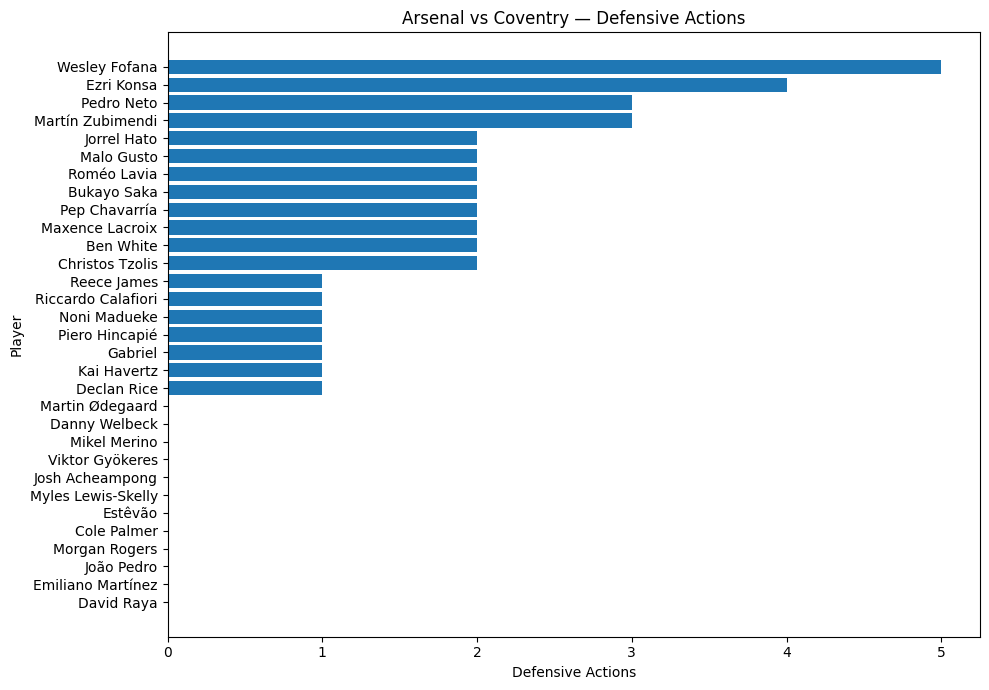

In [ ]:
import matplotlib.pyplot as plt

df = defensive_df.copy()

# Remove players with no minutes
df = df[df["minutes"].notna()].copy()

# Sort by defensive actions
df = df.sort_values("defensive_actions", ascending=True)

plt.figure(figsize=(10, 7))

plt.barh(
    df["player"],
    df["defensive_actions"]
)

plt.xlabel("Defensive Actions")
plt.ylabel("Player")
plt.title("Arsenal vs Coventry — Defensive Actions")

plt.tight_layout()
plt.show()

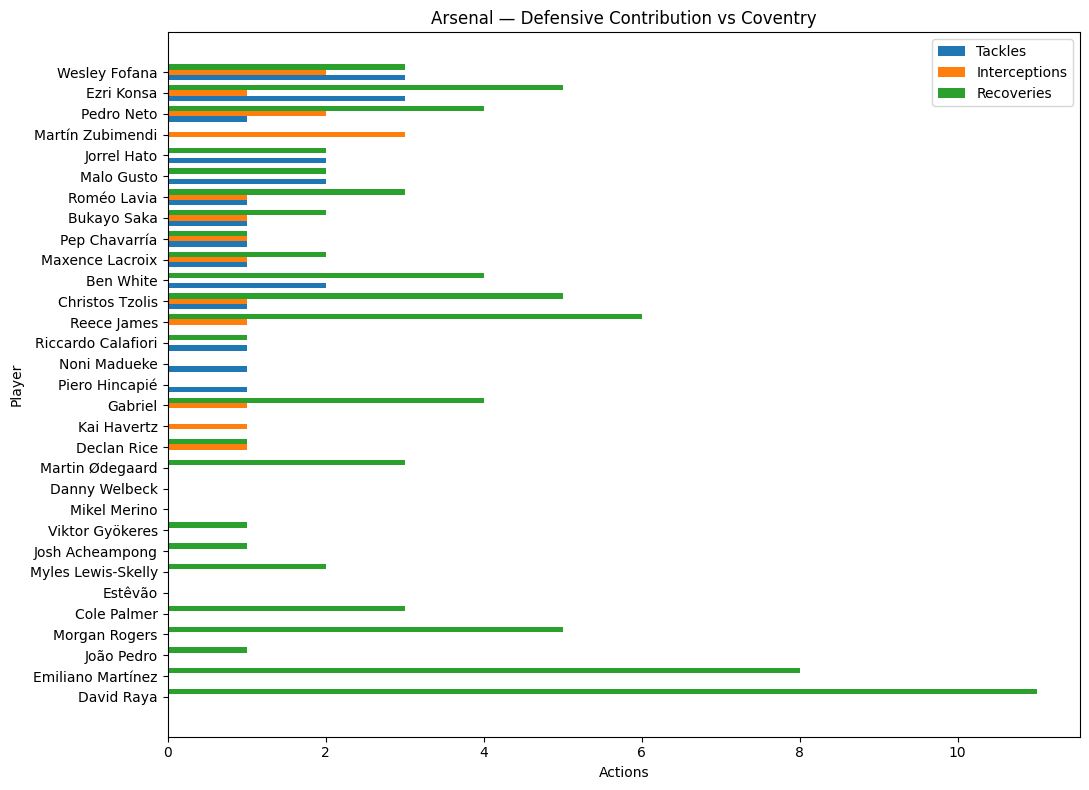

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

df = defensive_df.copy()
df = df[df["minutes"].notna()].copy()

df = df.sort_values("defensive_actions", ascending=True)

y = np.arange(len(df))
height = 0.25

plt.figure(figsize=(11, 8))

plt.barh(
    y - height,
    df["tackles"],
    height,
    label="Tackles"
)

plt.barh(
    y,
    df["interceptions"],
    height,
    label="Interceptions"
)

plt.barh(
    y + height,
    df["recoveries"],
    height,
    label="Recoveries"
)

plt.yticks(y, df["player"])
plt.xlabel("Actions")
plt.ylabel("Player")
plt.title("Arsenal — Defensive Contribution vs Coventry")
plt.legend()

plt.tight_layout()
plt.show()

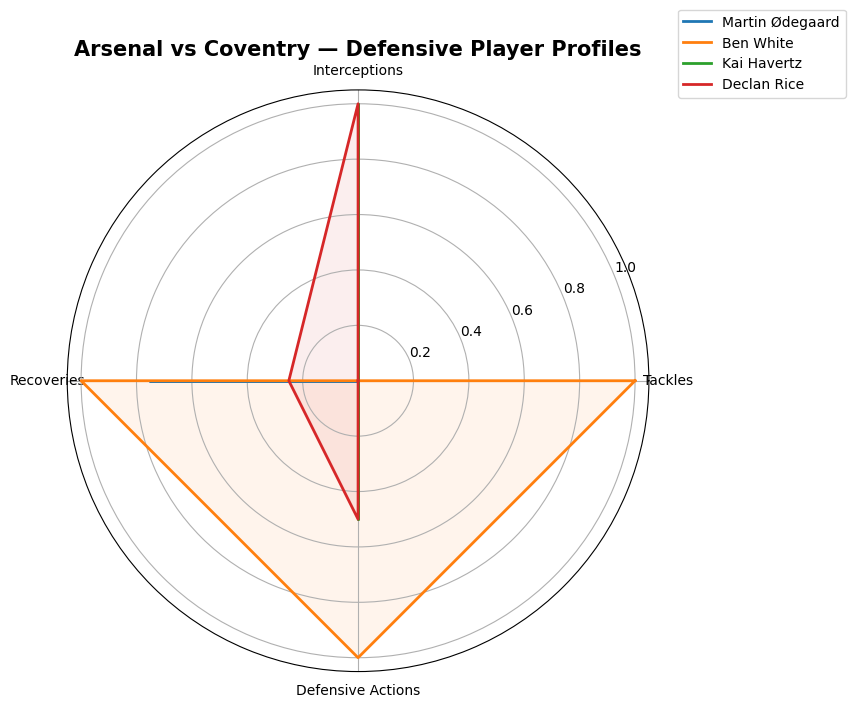

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Select players
players = [
    "Martin Ødegaard",
    "Ben White",
    "Kai Havertz",
    "Declan Rice"
]

df = defensive_df[
    defensive_df["player"].isin(players)
].copy()

# Metrics
metrics = [
    "tackles",
    "interceptions",
    "recoveries",
    "defensive_actions"
]

labels = [
    "Tackles",
    "Interceptions",
    "Recoveries",
    "Defensive Actions"
]

# Normalize each metric so the radar is easier to compare
radar_df = df.set_index("player")[metrics].fillna(0)

max_values = radar_df.max()
radar_df = radar_df / max_values

# Radar angles
angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False)
angles = np.concatenate([angles, [angles[0]]])

fig = plt.figure(figsize=(9, 9))
ax = plt.subplot(111, polar=True)

for player in players:
    values = radar_df.loc[player].values
    values = np.concatenate([values, [values[0]]])

    ax.plot(angles, values, linewidth=2, label=player)
    ax.fill(angles, values, alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)

ax.set_title(
    "Arsenal vs Coventry — Defensive Player Profiles",
    pad=25,
    fontsize=15,
    fontweight="bold"
)

ax.legend(
    loc="upper right",
    bbox_to_anchor=(1.35, 1.15)
)

plt.tight_layout()
plt.show()

In [ ]:
def get_player_image(player_id):
    return f"https://images.fotmob.com/image_resources/playerimages/{int(player_id)}.png"

In [ ]:
print(final_player_df.columns.tolist())

['player', 'minutes', 'passes', 'chances_created', 'tackles', 'interceptions', 'recoveries', 'ground_duels_won', 'aerial_duels_won', 'understat_shots', 'understat_xG', 'understat_xG_per_shot', 'understat_goals', 'understat_finishing_diff']


In [ ]:
print(final_player_df.index)

Index([ 0,  1,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 14, 16, 17, 18, 19, 20,
       21, 22, 23, 24, 26, 28, 29, 30, 31, 34, 35, 36, 38],
      dtype='int64')


In [ ]:
# ============================================================
# FOTMOB PLAYER IDs
# ASTON VILLA + ARSENAL
# ============================================================

player_ids = {

    # ========================================================
    # ARSENAL
    # ========================================================

    "Martin Ødegaard": 534670,
    "David Raya": 562727,
    "Declan Rice": 654096,
    "Kai Havertz": 749736,
    "Ben White": 776151,
    "Gabriel": 795179,
    "Bukayo Saka": 961995,
    "Riccardo Calafiori": 1105912,
    "Christos Tzolis": 1157237,
    "Cristhian Mosquera": 1298907,
    "Myles Lewis-Skelly": 1406436,
    "Noni Madueke": 1084981,
    "Mikel Merino": 574645,
    "Eberechi Eze": 818975,
    "Martín Zubimendi": 1031325,
    "Piero Hincapié": 1137667,
    "Viktor Gyökeres": 664500,
    "Ezri Konsa": 710159,


# ========================================================
# CHELSEA
# ========================================================


    "Emiliano Martínez": 268375,
    "Reece James": 807729,
    "Pedro Neto": 843040,
    "Morgan Rogers": 883080,
    "Wesley Fofana": 917802,
    "Maxence Lacroix": 950485,
    "Pep Chavarría": 988805,
    "João Pedro": 1021382,
    "Cole Palmer": 1096353,
    "Roméo Lavia": 1190867,
    "Malo Gusto": 1197250,
    "Josh Acheampong": 1400216,
    "Jorrel Hato": 1413846,
    "Estêvão": 1580774,
}

In [ ]:
df = final_player_df.copy()

# Only players who played
df = df[df["minutes"] > 0].copy()

# Add player ID
df["player_id"] = df["player"].map(player_ids)

# Create FotMob image URL
df["image_url"] = df["player_id"].apply(
    lambda x: (
        f"https://images.fotmob.com/image_resources/playerimages/{int(x)}.png"
        if pd.notna(x)
        else None
    )
)

print(
    df[["player", "player_id", "image_url"]]
    .to_string(index=False)
)

            player  player_id                                                          image_url
     Danny Welbeck        NaN                                                               None
 Emiliano Martínez   268375.0  https://images.fotmob.com/image_resources/playerimages/268375.png
   Martin Ødegaard   534670.0  https://images.fotmob.com/image_resources/playerimages/534670.png
        David Raya   562727.0  https://images.fotmob.com/image_resources/playerimages/562727.png
      Mikel Merino   574645.0  https://images.fotmob.com/image_resources/playerimages/574645.png
       Declan Rice   654096.0  https://images.fotmob.com/image_resources/playerimages/654096.png
   Viktor Gyökeres   664500.0  https://images.fotmob.com/image_resources/playerimages/664500.png
        Ezri Konsa   710159.0  https://images.fotmob.com/image_resources/playerimages/710159.png
       Kai Havertz   749736.0  https://images.fotmob.com/image_resources/playerimages/749736.png
         Ben White   776151.0 

In [ ]:
print(final_player_df.columns.tolist())

['player', 'minutes', 'passes', 'chances_created', 'tackles', 'interceptions', 'recoveries', 'ground_duels_won', 'aerial_duels_won', 'understat_shots', 'understat_xG', 'understat_xG_per_shot', 'understat_goals', 'understat_finishing_diff']


✅ All players have FotMob IDs.
✅ All players assigned to a team.

ARSENAL vs CHELSEA — PLAYER MAPPING
            player    team  minutes  player_id
        David Raya Arsenal     90.0   562727.0
       Declan Rice Arsenal     90.0   654096.0
         Ben White Arsenal     90.0   776151.0
           Gabriel Arsenal     90.0   795179.0
   Christos Tzolis Arsenal     90.0  1157237.0
       Bukayo Saka Arsenal     89.0   961995.0
       Kai Havertz Arsenal     78.0   749736.0
   Martin Ødegaard Arsenal     77.0   534670.0
Riccardo Calafiori Arsenal     67.0  1105912.0
Myles Lewis-Skelly Arsenal     67.0  1406436.0
  Martín Zubimendi Arsenal     23.0  1031325.0
    Piero Hincapié Arsenal     23.0  1137667.0
      Mikel Merino Arsenal     13.0   574645.0
      Noni Madueke Arsenal      1.0  1084981.0
 Emiliano Martínez Chelsea     90.0   268375.0
       Reece James Chelsea     90.0   807729.0
     Wesley Fofana Chelsea     90.0   917802.0
   Maxence Lacroix Chelsea     90.0   950485.0
     

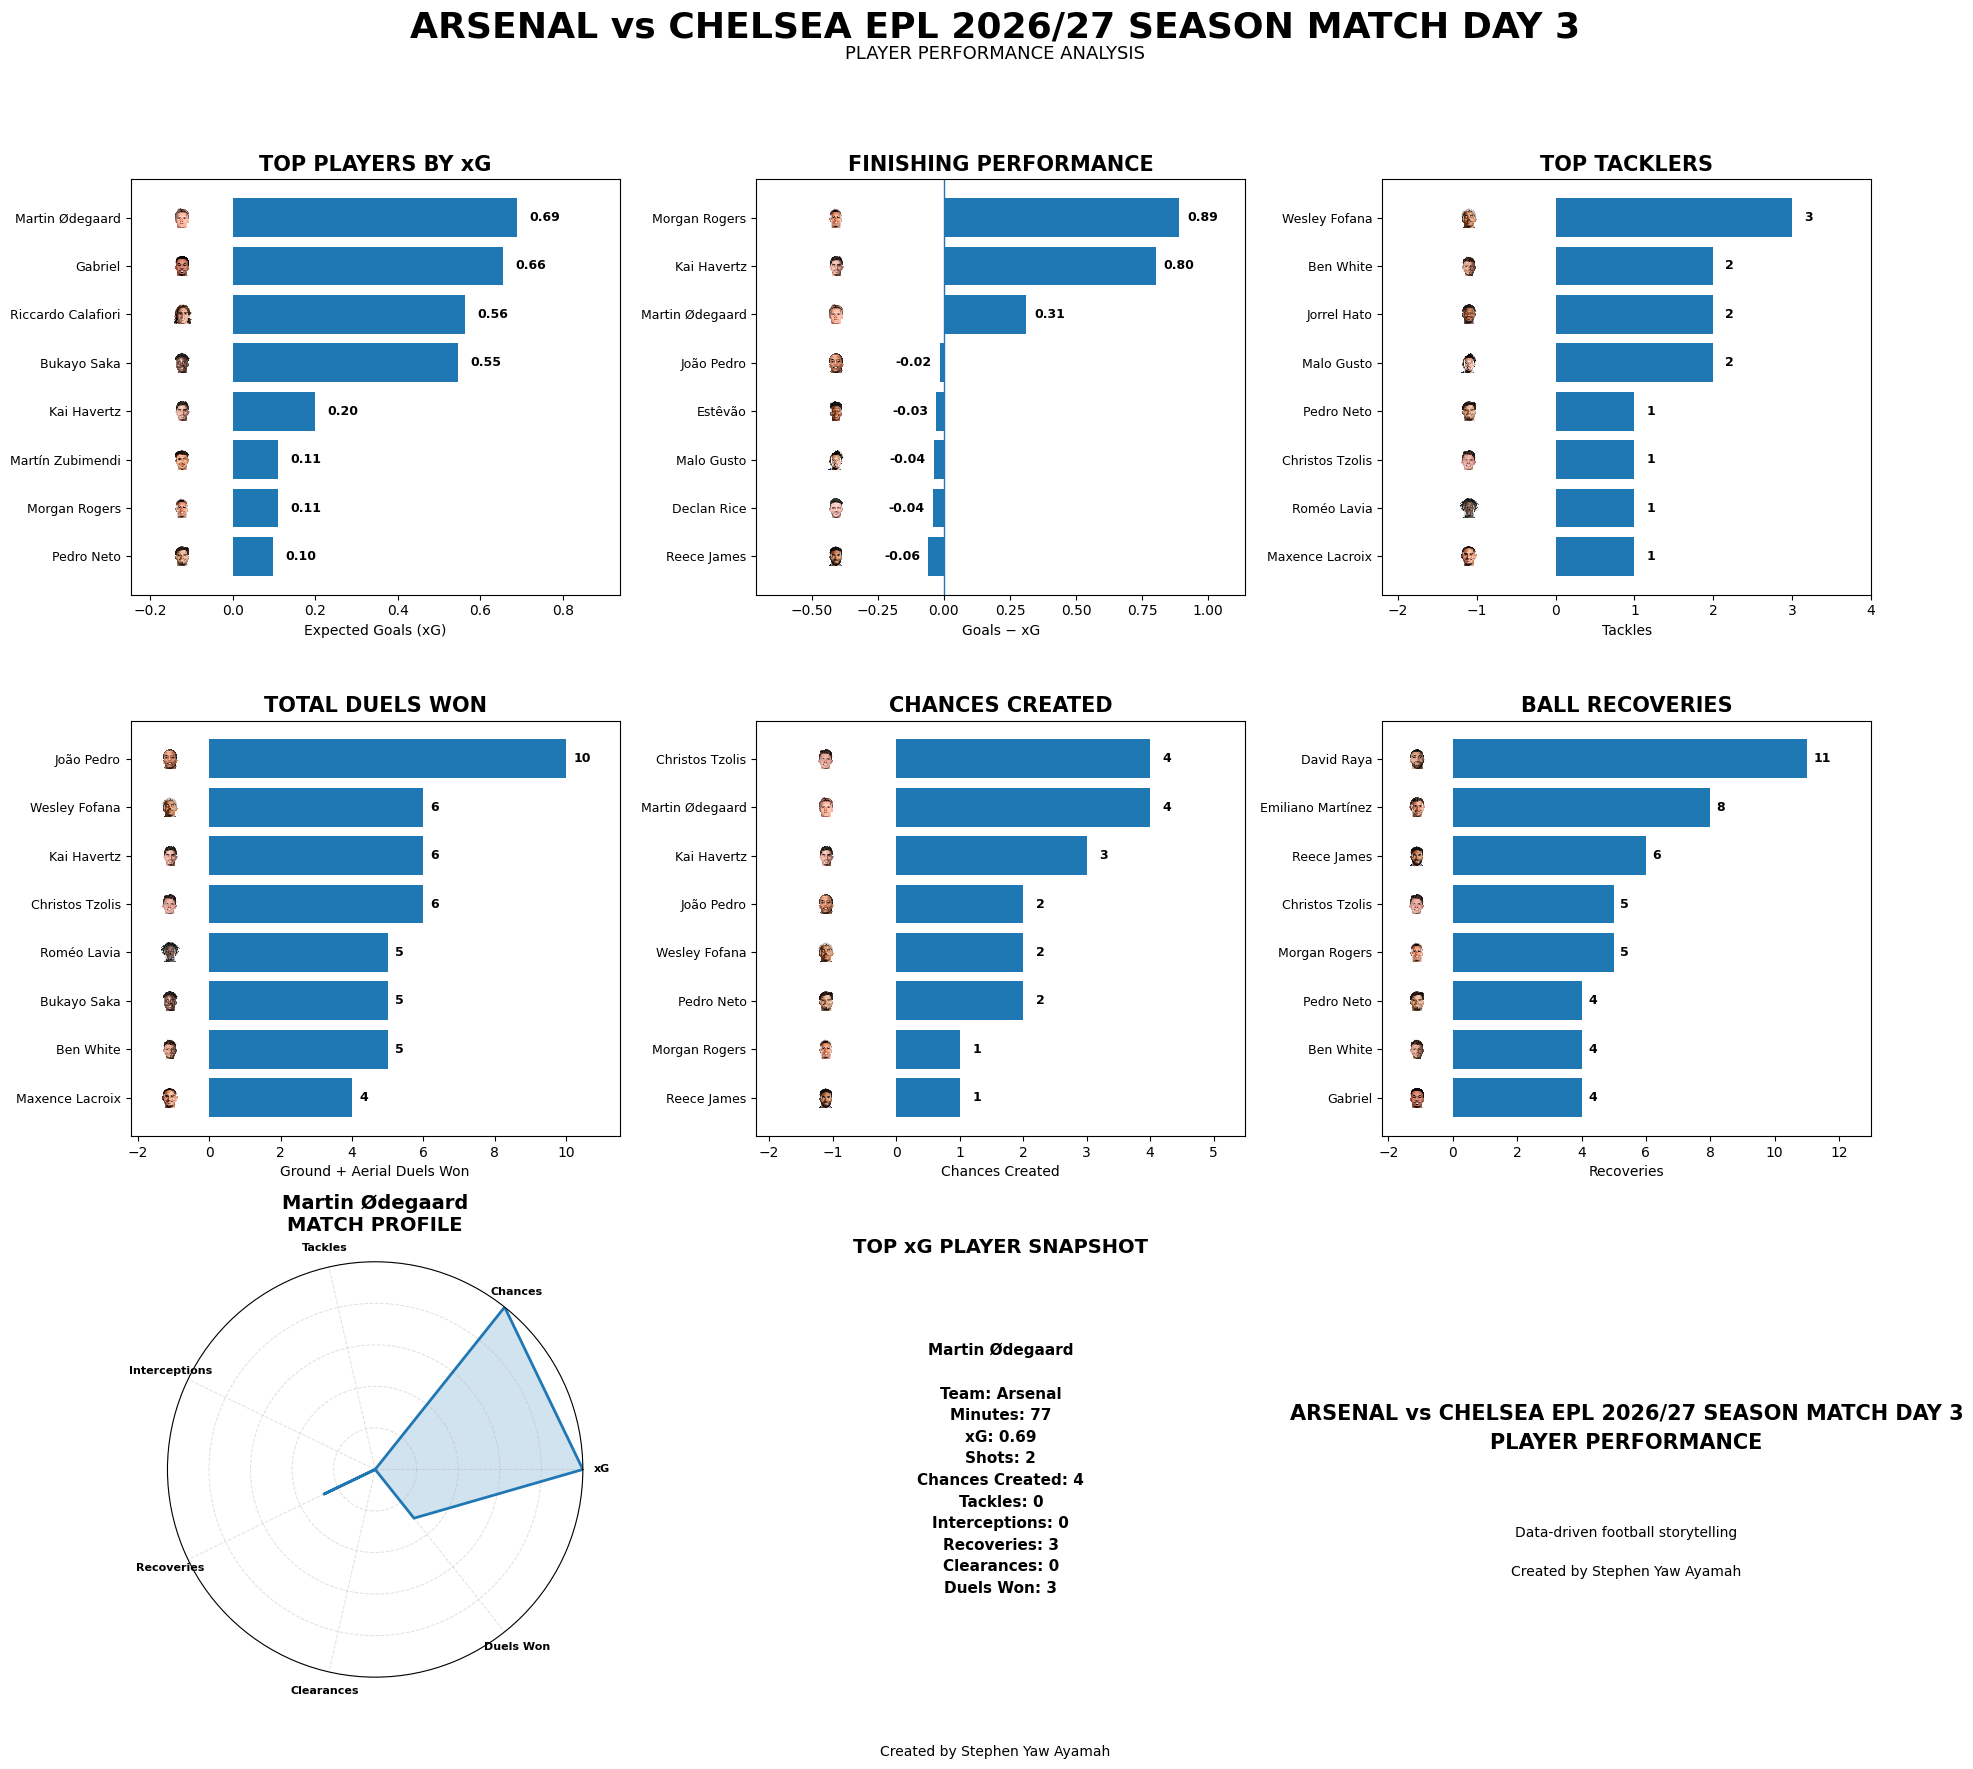

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

from PIL import Image
from io import BytesIO
from matplotlib.offsetbox import OffsetImage, AnnotationBbox


# ============================================================
# CONFIGURATION
# ============================================================

MATCH_TITLE = "ARSENAL vs CHELSEA EPL 2026/27 SEASON MATCH DAY 3"
SUBTITLE = "PLAYER PERFORMANCE ANALYSIS"
CREATOR = "Stephen Yaw Ayamah"


# ============================================================
# PLAYER IDs
# ============================================================

player_ids = {

    # ========================================================
    # ARSENAL
    # ========================================================

    "Martin Ødegaard": 534670,
    "David Raya": 562727,
    "Declan Rice": 654096,
    "Kai Havertz": 749736,
    "Ben White": 776151,
    "Gabriel": 795179,
    "Bukayo Saka": 961995,
    "Riccardo Calafiori": 1105912,
    "Christos Tzolis": 1157237,
    "Cristhian Mosquera": 1298907,
    "Myles Lewis-Skelly": 1406436,
    "Mikel Merino": 574645,
    "Eberechi Eze": 818975,
    "Martín Zubimendi": 1031325,
    "Piero Hincapié": 1137667,
    "Noni Madueke": 1084981,


    # ========================================================
    # CHELSEA
    # ========================================================

    "Emiliano Martínez": 268375,
    "Reece James": 807729,
    "Pedro Neto": 843040,
    "Morgan Rogers": 883080,
    "Wesley Fofana": 917802,
    "Maxence Lacroix": 950485,
    "Pep Chavarría": 988805,
    "João Pedro": 1021382,
    "Cole Palmer": 1096353,
    "Roméo Lavia": 1190867,
    "Malo Gusto": 1197250,
    "Josh Acheampong": 1400216,
    "Jorrel Hato": 1413846,
    "Estêvão": 1580774,
}


# ============================================================
# TEAM PLAYER SETS
# ============================================================

arsenal_players = {

    "Martin Ødegaard",
    "David Raya",
    "Declan Rice",
    "Kai Havertz",
    "Ben White",
    "Gabriel",
    "Bukayo Saka",
    "Riccardo Calafiori",
    "Christos Tzolis",
    "Cristhian Mosquera",
    "Myles Lewis-Skelly",
    "Mikel Merino",
    "Eberechi Eze",
    "Martín Zubimendi",
    "Piero Hincapié",
    "Noni Madueke",
}


chelsea_players = {

    "Emiliano Martínez",
    "Reece James",
    "Pedro Neto",
    "Morgan Rogers",
    "Wesley Fofana",
    "Maxence Lacroix",
    "Pep Chavarría",
    "João Pedro",
    "Cole Palmer",
    "Roméo Lavia",
    "Malo Gusto",
    "Josh Acheampong",
    "Jorrel Hato",
    "Estêvão",
}


# ============================================================
# HELPER — LOAD PLAYER IMAGE
# ============================================================

def add_player_image(
    ax,
    image_url,
    x,
    y,
    zoom=0.085
):

    if image_url is None or pd.isna(image_url):
        return

    try:

        response = requests.get(
            image_url,
            timeout=8
        )

        response.raise_for_status()

        image = Image.open(
            BytesIO(response.content)
        ).convert("RGBA")

        imagebox = OffsetImage(
            image,
            zoom=zoom
        )

        annotation = AnnotationBbox(
            imagebox,
            (x, y),
            frameon=False,
            box_alignment=(0.5, 0.5),
            annotation_clip=False
        )

        ax.add_artist(annotation)

    except Exception:
        pass


# ============================================================
# HELPER — BAR VALUE LABELS
# ============================================================

def add_bar_values(
    ax,
    bars,
    decimals=0,
    offset=0.15
):

    for bar in bars:

        value = bar.get_width()

        y = (
            bar.get_y()
            + bar.get_height() / 2
        )

        label = f"{value:.{decimals}f}"

        if value >= 0:

            ax.text(
                value + offset,
                y,
                label,
                va="center",
                ha="left",
                fontsize=9,
                fontweight="bold"
            )

        else:

            ax.text(
                value - offset,
                y,
                label,
                va="center",
                ha="right",
                fontsize=9,
                fontweight="bold"
            )


# ============================================================
# PREPARE DATA
# ============================================================

df = final_player_df.copy()


# ============================================================
# ONLY PLAYERS WHO PLAYED
# ============================================================

df["minutes"] = pd.to_numeric(
    df["minutes"],
    errors="coerce"
)

df = df[
    df["minutes"] > 0
].copy()


# ============================================================
# PLAYER IDs
# ============================================================

df["player_id"] = (
    df["player"]
    .map(player_ids)
)


# ============================================================
# TEAM ASSIGNMENT
# ============================================================

df["team"] = np.select(

    [
        df["player"].isin(arsenal_players),
        df["player"].isin(chelsea_players)
    ],

    [
        "Arsenal",
        "Chelsea"
    ],

    default="Unknown"
)


# ============================================================
# FOTMOB IMAGE URL
# ============================================================

df["image_url"] = df["player_id"].apply(

    lambda x:

        (
            f"https://images.fotmob.com/"
            f"image_resources/playerimages/"
            f"{int(x)}.png"
        )

        if pd.notna(x)

        else None
)


# ============================================================
# REQUIRED METRICS
# ============================================================

required_metrics = [

    "understat_xG",
    "understat_shots",
    "understat_finishing_diff",

    "tackles",
    "interceptions",
    "recoveries",

    "chances_created",

    "ground_duels_won",
    "aerial_duels_won",
]


# ============================================================
# CHECK COLUMNS
# ============================================================

missing_metrics = [

    col
    for col in required_metrics
    if col not in df.columns

]


if missing_metrics:

    raise KeyError(
        "Missing required columns: "
        f"{missing_metrics}"
    )


# ============================================================
# CLEARANCES
# ============================================================

if "clearances" not in df.columns:

    df["clearances"] = 0


# ============================================================
# NUMERIC CLEANING
# ============================================================

numeric_cols = df.select_dtypes(
    include="number"
).columns


df[numeric_cols] = (
    df[numeric_cols]
    .fillna(0)
)


# ============================================================
# TOTAL DUELS WON
# ============================================================

df["total_duels_won"] = (

    df["ground_duels_won"]
    +
    df["aerial_duels_won"]

)


# ============================================================
# KEEP ONLY ARSENAL + CHELSEA
# ============================================================

df = df[
    df["team"].isin(
        [
            "Arsenal",
            "Chelsea"
        ]
    )
].copy()


# ============================================================
# VALIDATION — FOTMOB IDS
# ============================================================

missing_ids = (

    df[
        df["player_id"].isna()
    ][
        [
            "player",
            "team"
        ]
    ]

    .drop_duplicates()

)


if not missing_ids.empty:

    print(
        "\n⚠️ PLAYERS WITHOUT FOTMOB IDs"
    )

    print(
        missing_ids.to_string(
            index=False
        )
    )

else:

    print(
        "✅ All players have FotMob IDs."
    )


# ============================================================
# VALIDATION — UNKNOWN PLAYERS
# ============================================================

unknown_players = (

    df[
        df["team"] == "Unknown"
    ][
        ["player"]
    ]

    .drop_duplicates()

)


if not unknown_players.empty:

    print(
        "\n⚠️ UNKNOWN PLAYERS"
    )

    print(
        unknown_players.to_string(
            index=False
        )
    )

else:

    print(
        "✅ All players assigned to a team."
    )


# ============================================================
# PRINT PLAYER MAPPING
# ============================================================

print(
    "\n" + "=" * 70
)

print(
    "ARSENAL vs CHELSEA — PLAYER MAPPING"
)

print(
    "=" * 70
)

print(

    df[
        [
            "player",
            "team",
            "minutes",
            "player_id"
        ]
    ]

    .drop_duplicates()

    .sort_values(
        [
            "team",
            "minutes"
        ],
        ascending=[
            True,
            False
        ]
    )

    .to_string(
        index=False
    )

)


# ============================================================
# TOP xG PLAYER
# ============================================================

top_player = (

    df

    .sort_values(
        "understat_xG",
        ascending=False
    )

    .iloc[0]

)


player_name = top_player["player"]


# ============================================================
# CREATE FIGURE
# ============================================================

fig = plt.figure(
    figsize=(20, 18)
)


fig.suptitle(
    MATCH_TITLE,
    fontsize=26,
    fontweight="bold",
    y=0.985
)


fig.text(
    0.5,
    0.958,
    SUBTITLE,
    ha="center",
    fontsize=13
)


# ============================================================
# 1 — TOP xG
# ============================================================

ax1 = plt.subplot(
    3,
    3,
    1
)


top_xg = (

    df

    .sort_values(
        "understat_xG",
        ascending=False
    )

    .head(8)

    .sort_values(
        "understat_xG"
    )

)


bars = ax1.barh(
    top_xg["player"],
    top_xg["understat_xG"]
)


add_bar_values(
    ax1,
    bars,
    decimals=2,
    offset=0.03
)


ax1.set_yticks(
    np.arange(
        len(top_xg)
    )
)


ax1.set_yticklabels(
    top_xg["player"],
    fontsize=9
)


image_x = (
    -top_xg["understat_xG"].max()
    * 0.18
)


for i, (_, row) in enumerate(
    top_xg.iterrows()
):

    add_player_image(
        ax1,
        row["image_url"],
        image_x,
        i,
        zoom=0.075
    )


ax1.set_xlim(
    left=image_x * 2.0,
    right=(
        top_xg["understat_xG"].max()
        + 0.25
    )
)


ax1.set_title(
    "TOP PLAYERS BY xG",
    fontsize=15,
    fontweight="bold"
)


ax1.set_xlabel(
    "Expected Goals (xG)"
)


# ============================================================
# 2 — FINISHING PERFORMANCE
# ============================================================

ax2 = plt.subplot(
    3,
    3,
    2
)


finishing = (

    df[
        df["understat_shots"] > 0
    ]

    .sort_values(
        "understat_finishing_diff"
    )

    .tail(8)

)


finishing = finishing.sort_values(
    "understat_finishing_diff"
)


bars = ax2.barh(
    finishing["player"],
    finishing["understat_finishing_diff"]
)


add_bar_values(
    ax2,
    bars,
    decimals=2,
    offset=0.03
)


ax2.set_yticks(
    np.arange(
        len(finishing)
    )
)


ax2.set_yticklabels(
    finishing["player"],
    fontsize=9
)


data_min = (
    finishing[
        "understat_finishing_diff"
    ].min()
)


data_max = (
    finishing[
        "understat_finishing_diff"
    ].max()
)


image_x = data_min - 0.35


for i, (_, row) in enumerate(
    finishing.iterrows()
):

    add_player_image(
        ax2,
        row["image_url"],
        image_x,
        i,
        zoom=0.075
    )


ax2.axvline(
    0,
    linewidth=1
)


ax2.set_xlim(
    left=data_min - 0.65,
    right=data_max + 0.25
)


ax2.set_title(
    "FINISHING PERFORMANCE",
    fontsize=15,
    fontweight="bold"
)


ax2.set_xlabel(
    "Goals − xG"
)


# ============================================================
# 3 — TOP TACKLERS
# ============================================================

ax3 = plt.subplot(
    3,
    3,
    3
)


defensive = (

    df

    .sort_values(
        [
            "tackles",
            "interceptions",
            "recoveries"
        ],
        ascending=False
    )

    .head(8)

    .sort_values(
        "tackles"
    )

)


bars = ax3.barh(
    defensive["player"],
    defensive["tackles"]
)


add_bar_values(
    ax3,
    bars,
    decimals=0,
    offset=0.15
)


ax3.set_yticks(
    np.arange(
        len(defensive)
    )
)


ax3.set_yticklabels(
    defensive["player"],
    fontsize=9
)


for i, (_, row) in enumerate(
    defensive.iterrows()
):

    add_player_image(
        ax3,
        row["image_url"],
        -1.1,
        i,
        zoom=0.075
    )


ax3.set_xlim(
    left=-2.2,
    right=(
        defensive["tackles"].max()
        + 1
    )
)


ax3.set_title(
    "TOP TACKLERS",
    fontsize=15,
    fontweight="bold"
)


ax3.set_xlabel(
    "Tackles"
)


# ============================================================
# 4 — TOTAL DUELS WON
# ============================================================

ax4 = plt.subplot(
    3,
    3,
    4
)


duels = (

    df

    .sort_values(
        "total_duels_won",
        ascending=False
    )

    .head(8)

    .sort_values(
        "total_duels_won"
    )

)


bars = ax4.barh(
    duels["player"],
    duels["total_duels_won"]
)


add_bar_values(
    ax4,
    bars,
    decimals=0,
    offset=0.20
)


ax4.set_yticks(
    np.arange(
        len(duels)
    )
)


ax4.set_yticklabels(
    duels["player"],
    fontsize=9
)


for i, (_, row) in enumerate(
    duels.iterrows()
):

    add_player_image(
        ax4,
        row["image_url"],
        -1.1,
        i,
        zoom=0.075
    )


ax4.set_xlim(
    left=-2.2,
    right=(
        duels["total_duels_won"].max()
        + 1.5
    )
)


ax4.set_title(
    "TOTAL DUELS WON",
    fontsize=15,
    fontweight="bold"
)


ax4.set_xlabel(
    "Ground + Aerial Duels Won"
)


# ============================================================
# 5 — CHANCES CREATED
# ============================================================

ax5 = plt.subplot(
    3,
    3,
    5
)


chances = (

    df

    .sort_values(
        "chances_created",
        ascending=False
    )

    .head(8)

    .sort_values(
        "chances_created"
    )

)


bars = ax5.barh(
    chances["player"],
    chances["chances_created"]
)


add_bar_values(
    ax5,
    bars,
    decimals=0,
    offset=0.20
)


ax5.set_yticks(
    np.arange(
        len(chances)
    )
)


ax5.set_yticklabels(
    chances["player"],
    fontsize=9
)


for i, (_, row) in enumerate(
    chances.iterrows()
):

    add_player_image(
        ax5,
        row["image_url"],
        -1.1,
        i,
        zoom=0.075
    )


ax5.set_xlim(
    left=-2.2,
    right=(
        chances["chances_created"].max()
        + 1.5
    )
)


ax5.set_title(
    "CHANCES CREATED",
    fontsize=15,
    fontweight="bold"
)


ax5.set_xlabel(
    "Chances Created"
)


# ============================================================
# 6 — RECOVERIES
# ============================================================

ax6 = plt.subplot(
    3,
    3,
    6
)


recoveries = (

    df

    .sort_values(
        "recoveries",
        ascending=False
    )

    .head(8)

    .sort_values(
        "recoveries"
    )

)


bars = ax6.barh(
    recoveries["player"],
    recoveries["recoveries"]
)


add_bar_values(
    ax6,
    bars,
    decimals=0,
    offset=0.20
)


ax6.set_yticks(
    np.arange(
        len(recoveries)
    )
)


ax6.set_yticklabels(
    recoveries["player"],
    fontsize=9
)


for i, (_, row) in enumerate(
    recoveries.iterrows()
):

    add_player_image(
        ax6,
        row["image_url"],
        -1.1,
        i,
        zoom=0.075
    )


ax6.set_xlim(
    left=-2.2,
    right=(
        recoveries["recoveries"].max()
        + 2
    )
)


ax6.set_title(
    "BALL RECOVERIES",
    fontsize=15,
    fontweight="bold"
)


ax6.set_xlabel(
    "Recoveries"
)


# ============================================================
# 7 — RADAR PROFILE
# ============================================================

ax7 = plt.subplot(
    3,
    3,
    7,
    polar=True
)


radar_metrics = [

    "understat_xG",
    "chances_created",
    "tackles",
    "interceptions",
    "recoveries",
    "clearances",
    "total_duels_won"

]


radar_labels = [

    "xG",
    "Chances",
    "Tackles",
    "Interceptions",
    "Recoveries",
    "Clearances",
    "Duels Won"

]


radar_values = []


for metric in radar_metrics:

    maximum = df[metric].max()

    player_value = top_player[metric]

    if maximum > 0:

        normalized = (
            player_value / maximum
        )

    else:

        normalized = 0

    radar_values.append(
        normalized
    )


values_closed = (

    radar_values
    +
    radar_values[:1]

)


angles = np.linspace(

    0,
    2 * np.pi,
    len(radar_metrics),
    endpoint=False

)


angles_closed = np.concatenate(

    [
        angles,
        angles[:1]
    ]

)


ax7.plot(
    angles_closed,
    values_closed,
    linewidth=2
)


ax7.fill(
    angles_closed,
    values_closed,
    alpha=0.20
)


ax7.set_xticks(
    angles
)


ax7.set_xticklabels(
    radar_labels,
    fontsize=8,
    fontweight="bold"
)


ax7.set_ylim(
    0,
    1
)


ax7.set_yticklabels([])


ax7.grid(
    True,
    linestyle="--",
    linewidth=0.7,
    alpha=0.4
)


ax7.set_title(
    f"{player_name}\nMATCH PROFILE",
    fontsize=14,
    fontweight="bold",
    pad=22
)


# ============================================================
# 8 — TOP PLAYER SNAPSHOT
# ============================================================

ax8 = plt.subplot(
    3,
    3,
    8
)


ax8.axis("off")


summary_text = (

    f"{player_name}\n\n"

    f"Team: "
    f"{top_player['team']}\n"

    f"Minutes: "
    f"{top_player['minutes']:.0f}\n"

    f"xG: "
    f"{top_player['understat_xG']:.2f}\n"

    f"Shots: "
    f"{top_player['understat_shots']:.0f}\n"

    f"Chances Created: "
    f"{top_player['chances_created']:.0f}\n"

    f"Tackles: "
    f"{top_player['tackles']:.0f}\n"

    f"Interceptions: "
    f"{top_player['interceptions']:.0f}\n"

    f"Recoveries: "
    f"{top_player['recoveries']:.0f}\n"

    f"Clearances: "
    f"{top_player['clearances']:.0f}\n"

    f"Duels Won: "
    f"{top_player['total_duels_won']:.0f}"

)


ax8.text(

    0.5,
    0.5,
    summary_text,

    transform=ax8.transAxes,

    ha="center",
    va="center",

    fontsize=11,
    fontweight="bold",

    linespacing=1.55

)


ax8.set_title(

    "TOP xG PLAYER SNAPSHOT",

    fontsize=14,
    fontweight="bold"

)


# ============================================================
# 9 — ANALYTICS STORY
# ============================================================

ax9 = plt.subplot(
    3,
    3,
    9
)


ax9.axis("off")


ax9.text(

    0.5,
    0.60,

    f"{MATCH_TITLE}\n"
    "PLAYER PERFORMANCE",

    transform=ax9.transAxes,

    ha="center",
    va="center",

    fontsize=15,
    fontweight="bold",

    linespacing=1.6

)


ax9.text(

    0.5,
    0.30,

    "Data-driven football storytelling\n\n"
    f"Created by {CREATOR}",

    transform=ax9.transAxes,

    ha="center",
    va="center",

    fontsize=10,

    linespacing=1.5

)


# ============================================================
# FINAL LAYOUT
# ============================================================

plt.tight_layout(

    rect=[
        0,
        0.04,
        1,
        0.94
    ]

)


# ============================================================
# FOOTER
# ============================================================

fig.text(

    0.5,
    0.015,

    f"Created by {CREATOR}",

    ha="center",

    fontsize=10

)


plt.show()


ARSENAL vs CHELSEA — DATA PREPARATION
Rows loaded    : 31
Columns loaded : 14

✅ All players have FotMob IDs.
✅ All players assigned to a team.

ARSENAL vs CHELSEA — PLAYER MAPPING
            player    team  minutes  player_id
        David Raya Arsenal     90.0   562727.0
       Declan Rice Arsenal     90.0   654096.0
         Ben White Arsenal     90.0   776151.0
           Gabriel Arsenal     90.0   795179.0
   Christos Tzolis Arsenal     90.0  1157237.0
       Bukayo Saka Arsenal     89.0   961995.0
       Kai Havertz Arsenal     78.0   749736.0
   Martin Ødegaard Arsenal     77.0   534670.0
Riccardo Calafiori Arsenal     67.0  1105912.0
Myles Lewis-Skelly Arsenal     67.0  1406436.0
  Martín Zubimendi Arsenal     23.0  1031325.0
    Piero Hincapié Arsenal     23.0  1137667.0
      Mikel Merino Arsenal     13.0   574645.0
      Noni Madueke Arsenal      1.0  1084981.0
 Emiliano Martínez Chelsea     90.0   268375.0
       Reece James Chelsea     90.0   807729.0
     Wesley Fofana 

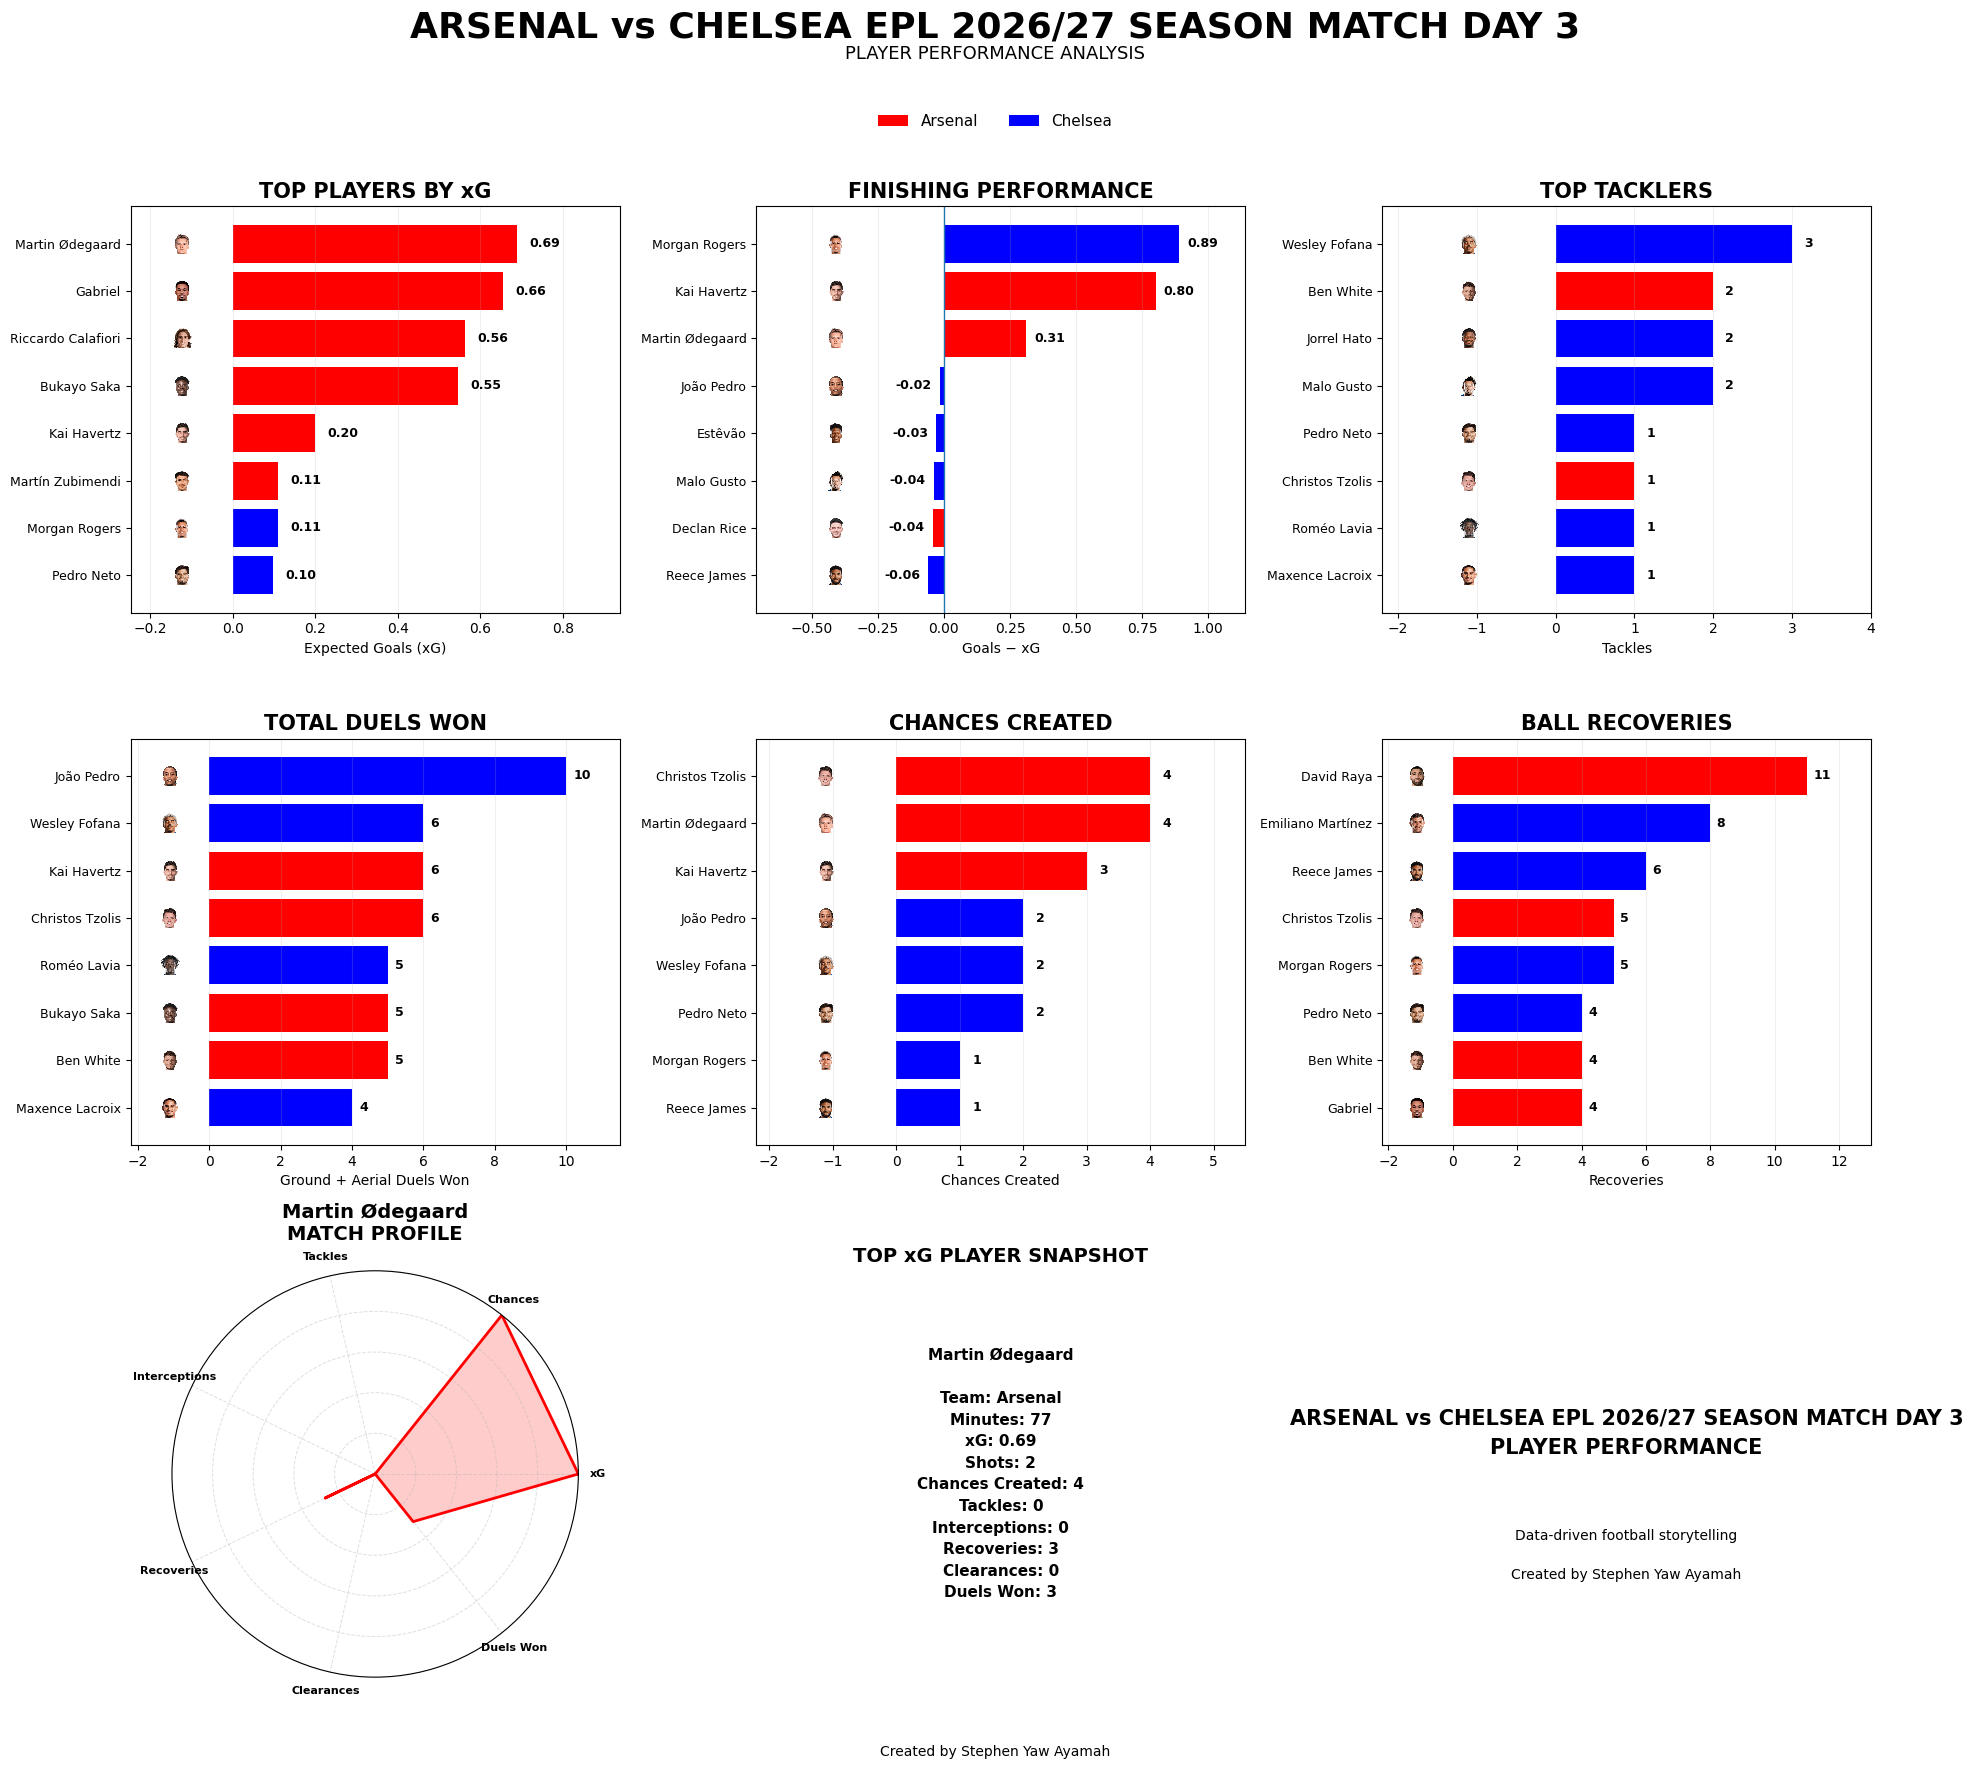

In [ ]:
# ============================================================
# ARSENAL vs CHELSEA EPL 2026/27 SEASON
# MATCH DAY 3
# PLAYER PERFORMANCE ANALYSIS
# 3 × 3 FOOTBALL DATA STORYTELLING DASHBOARD
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

from PIL import Image
from io import BytesIO
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from matplotlib.patches import Patch


# ============================================================
# CONFIGURATION
# ============================================================

MATCH_TITLE = (
    "ARSENAL vs CHELSEA EPL 2026/27 SEASON MATCH DAY 3"
)

SUBTITLE = "PLAYER PERFORMANCE ANALYSIS"

CREATOR = "Stephen Yaw Ayamah"


# ============================================================
# TEAM COLORS
# ============================================================

TEAM_COLORS = {

    "Arsenal": "red",
    "Chelsea": "blue"

}


# ============================================================
# PLAYER IDs — FOTMOB
# ============================================================

player_ids = {

    # ========================================================
    # ARSENAL
    # ========================================================

    "Martin Ødegaard": 534670,
    "David Raya": 562727,
    "Declan Rice": 654096,
    "Kai Havertz": 749736,
    "Ben White": 776151,
    "Gabriel": 795179,
    "Bukayo Saka": 961995,
    "Riccardo Calafiori": 1105912,
    "Christos Tzolis": 1157237,
    "Cristhian Mosquera": 1298907,
    "Myles Lewis-Skelly": 1406436,
    "Mikel Merino": 574645,
    "Eberechi Eze": 818975,
    "Martín Zubimendi": 1031325,
    "Piero Hincapié": 1137667,
    "Noni Madueke": 1084981,

    # ========================================================
    # CHELSEA
    # ========================================================

    "Emiliano Martínez": 268375,
    "Reece James": 807729,
    "Pedro Neto": 843040,
    "Morgan Rogers": 883080,
    "Wesley Fofana": 917802,
    "Maxence Lacroix": 950485,
    "Pep Chavarría": 988805,
    "João Pedro": 1021382,
    "Cole Palmer": 1096353,
    "Roméo Lavia": 1190867,
    "Malo Gusto": 1197250,
    "Josh Acheampong": 1400216,
    "Jorrel Hato": 1413846,
    "Estêvão": 1580774,

}


# ============================================================
# TEAM PLAYER SETS
# ============================================================

arsenal_players = {

    "Martin Ødegaard",
    "David Raya",
    "Declan Rice",
    "Kai Havertz",
    "Ben White",
    "Gabriel",
    "Bukayo Saka",
    "Riccardo Calafiori",
    "Christos Tzolis",
    "Cristhian Mosquera",
    "Myles Lewis-Skelly",
    "Mikel Merino",
    "Eberechi Eze",
    "Martín Zubimendi",
    "Piero Hincapié",
    "Noni Madueke",

}


chelsea_players = {

    "Emiliano Martínez",
    "Reece James",
    "Pedro Neto",
    "Morgan Rogers",
    "Wesley Fofana",
    "Maxence Lacroix",
    "Pep Chavarría",
    "João Pedro",
    "Cole Palmer",
    "Roméo Lavia",
    "Malo Gusto",
    "Josh Acheampong",
    "Jorrel Hato",
    "Estêvão",

}


# ============================================================
# HELPER — FIND COLUMN
# ============================================================

def find_column(
    df,
    possible_names,
    required=True
):

    for column in possible_names:

        if column in df.columns:
            return column

    if required:

        raise KeyError(

            "\nCould not find any of these columns:\n"
            f"{possible_names}\n\n"
            "Available columns:\n"
            f"{list(df.columns)}"

        )

    return None


# ============================================================
# HELPER — LOAD PLAYER IMAGE
# ============================================================

def add_player_image(
    ax,
    image_url,
    x,
    y,
    zoom=0.085
):

    if image_url is None:

        return

    if pd.isna(image_url):

        return

    try:

        response = requests.get(
            image_url,
            timeout=8
        )

        response.raise_for_status()

        image = Image.open(
            BytesIO(response.content)
        ).convert("RGBA")

        imagebox = OffsetImage(
            image,
            zoom=zoom
        )

        annotation = AnnotationBbox(

            imagebox,

            (x, y),

            frameon=False,

            box_alignment=(0.5, 0.5),

            annotation_clip=False

        )

        ax.add_artist(annotation)

    except Exception:

        pass


# ============================================================
# HELPER — BAR VALUE LABELS
# ============================================================

def add_bar_values(
    ax,
    bars,
    decimals=0,
    offset=0.15
):

    for bar in bars:

        value = bar.get_width()

        y = (
            bar.get_y()
            +
            bar.get_height() / 2
        )

        label = (
            f"{value:.{decimals}f}"
        )

        if value >= 0:

            ax.text(

                value + offset,

                y,

                label,

                va="center",
                ha="left",

                fontsize=9,
                fontweight="bold"

            )

        else:

            ax.text(

                value - offset,

                y,

                label,

                va="center",
                ha="right",

                fontsize=9,
                fontweight="bold"

            )


# ============================================================
# PREPARE DATA
# ============================================================

if "final_player_df" not in globals():

    raise NameError(

        "final_player_df was not found.\n\n"
        "Please run the cell that creates "
        "final_player_df first."

    )


df = final_player_df.copy()


# ============================================================
# DISPLAY ORIGINAL COLUMNS
# ============================================================

print(
    "\n" + "=" * 70
)

print(
    "ARSENAL vs CHELSEA — DATA PREPARATION"
)

print(
    "=" * 70
)

print(
    f"Rows loaded    : {len(df)}"
)

print(
    f"Columns loaded : {len(df.columns)}"
)


# ============================================================
# PLAYER COLUMN
# ============================================================

PLAYER_COL = find_column(

    df,

    [
        "player",
        "Player",
        "player_name",
        "name",
        "full_name"
    ]

)


if PLAYER_COL != "player":

    df["player"] = df[PLAYER_COL]

else:

    df["player"] = df["player"]


# ============================================================
# MINUTES
# ============================================================

MINUTES_COL = find_column(

    df,

    [
        "minutes",
        "Minutes",
        "mins",
        "minutes_played"
    ]

)


df["minutes"] = pd.to_numeric(

    df[MINUTES_COL],

    errors="coerce"

).fillna(0)


# ============================================================
# ONLY PLAYERS WHO PLAYED
# ============================================================

df = df[
    df["minutes"] > 0
].copy()


# ============================================================
# ============================================================
# STANDARDIZE xG
# ============================================================
#
# YOUR DATA MAY CONTAIN:
#
# xG
# understat_xG
# xg
# expected_goals
#
# We convert whichever exists into:
#
# understat_xG
#
# ============================================================
# ============================================================

XG_COL = find_column(

    df,

    [
        "understat_xG",
        "xG",
        "xg",
        "expected_goals",
        "expected_xg"
    ]

)


df["understat_xG"] = pd.to_numeric(

    df[XG_COL],

    errors="coerce"

).fillna(0)


# ============================================================
# STANDARDIZE SHOTS
# ============================================================

SHOTS_COL = find_column(

    df,

    [
        "understat_shots",
        "shots",
        "Shots",
        "total_shots"
    ],

    required=False

)


if SHOTS_COL is not None:

    df["understat_shots"] = pd.to_numeric(

        df[SHOTS_COL],

        errors="coerce"

    ).fillna(0)

else:

    df["understat_shots"] = 0


# ============================================================
# STANDARDIZE FINISHING DIFFERENCE
# ============================================================

FINISHING_COL = find_column(

    df,

    [
        "understat_finishing_diff",
        "finishing_diff",
        "finishing_difference"
    ],

    required=False

)


if FINISHING_COL is not None:

    df["understat_finishing_diff"] = pd.to_numeric(

        df[FINISHING_COL],

        errors="coerce"

    ).fillna(0)

else:

    if "goals" in df.columns:

        goals_numeric = pd.to_numeric(

            df["goals"],

            errors="coerce"

        ).fillna(0)

        df["understat_finishing_diff"] = (

            goals_numeric
            -
            df["understat_xG"]

        )

    else:

        df["understat_finishing_diff"] = 0


# ============================================================
# STANDARDIZE DEFENSIVE METRICS
# ============================================================

TACKLES_COL = find_column(

    df,

    [
        "tackles",
        "Tackles",
        "total_tackles"
    ],

    required=False

)


INTERCEPTIONS_COL = find_column(

    df,

    [
        "interceptions",
        "Interceptions",
        "total_interceptions"
    ],

    required=False

)


RECOVERIES_COL = find_column(

    df,

    [
        "recoveries",
        "Recoveries",
        "ball_recoveries"
    ],

    required=False

)


CHANCES_COL = find_column(

    df,

    [
        "chances_created",
        "Chances Created",
        "chances",
        "key_passes"
    ],

    required=False

)


GROUND_DUELS_COL = find_column(

    df,

    [
        "ground_duels_won",
        "ground_duels_won_total"
    ],

    required=False

)


AERIAL_DUELS_COL = find_column(

    df,

    [
        "aerial_duels_won",
        "aerial_duels_won_total"
    ],

    required=False

)


CLEARANCES_COL = find_column(

    df,

    [
        "clearances",
        "Clearances",
        "total_clearances"
    ],

    required=False

)


# ============================================================
# CREATE NUMERIC STANDARDIZED METRICS
# ============================================================

def create_numeric_metric(
    df,
    source_column,
    output_column
):

    if source_column is None:

        df[output_column] = 0

    else:

        df[output_column] = pd.to_numeric(

            df[source_column],

            errors="coerce"

        ).fillna(0)


# ============================================================
# APPLY STANDARDIZATION
# ============================================================

create_numeric_metric(

    df,
    TACKLES_COL,
    "tackles"

)


create_numeric_metric(

    df,
    INTERCEPTIONS_COL,
    "interceptions"

)


create_numeric_metric(

    df,
    RECOVERIES_COL,
    "recoveries"

)


create_numeric_metric(

    df,
    CHANCES_COL,
    "chances_created"

)


create_numeric_metric(

    df,
    GROUND_DUELS_COL,
    "ground_duels_won"

)


create_numeric_metric(

    df,
    AERIAL_DUELS_COL,
    "aerial_duels_won"

)


create_numeric_metric(

    df,
    CLEARANCES_COL,
    "clearances"

)


# ============================================================
# TOTAL DUELS WON
# ============================================================

df["total_duels_won"] = (

    df["ground_duels_won"]
    +
    df["aerial_duels_won"]

)


# ============================================================
# PLAYER IDs
# ============================================================

df["player_id"] = (

    df["player"]
    .map(player_ids)

)


# ============================================================
# TEAM ASSIGNMENT
# ============================================================

df["team"] = np.select(

    [

        df["player"].isin(
            arsenal_players
        ),

        df["player"].isin(
            chelsea_players
        )

    ],

    [

        "Arsenal",
        "Chelsea"

    ],

    default="Unknown"

)


# ============================================================
# FOTMOB IMAGE URL
# ============================================================

df["image_url"] = df["player_id"].apply(

    lambda x:

        (

            f"https://images.fotmob.com/"
            f"image_resources/playerimages/"
            f"{int(x)}.png"

        )

        if pd.notna(x)

        else None

)


# ============================================================
# KEEP ONLY ARSENAL + CHELSEA
# ============================================================

df = df[

    df["team"].isin(

        [
            "Arsenal",
            "Chelsea"
        ]

    )

].copy()


# ============================================================
# NUMERIC CLEANING
# ============================================================

numeric_columns = [

    "minutes",

    "understat_xG",

    "understat_shots",

    "understat_finishing_diff",

    "tackles",

    "interceptions",

    "recoveries",

    "chances_created",

    "ground_duels_won",

    "aerial_duels_won",

    "clearances",

    "total_duels_won"

]


for column in numeric_columns:

    df[column] = pd.to_numeric(

        df[column],

        errors="coerce"

    ).fillna(0)


# ============================================================
# VALIDATION — PLAYER IDS
# ============================================================

missing_ids = (

    df[
        df["player_id"].isna()
    ]

    [
        [
            "player",
            "team"
        ]
    ]

    .drop_duplicates()

)


if not missing_ids.empty:

    print(
        "\n⚠️ PLAYERS WITHOUT FOTMOB IDs"
    )

    print(
        missing_ids.to_string(
            index=False
        )
    )

else:

    print(
        "\n✅ All players have FotMob IDs."
    )


# ============================================================
# VALIDATION — TEAM ASSIGNMENT
# ============================================================

unknown_players = (

    df[
        df["team"] == "Unknown"
    ]

    [
        ["player"]
    ]

    .drop_duplicates()

)


if not unknown_players.empty:

    print(
        "\n⚠️ UNKNOWN PLAYERS"
    )

    print(
        unknown_players.to_string(
            index=False
        )
    )

else:

    print(
        "✅ All players assigned to a team."
    )


# ============================================================
# PLAYER MAPPING
# ============================================================

print(
    "\n" + "=" * 70
)

print(
    "ARSENAL vs CHELSEA — PLAYER MAPPING"
)

print(
    "=" * 70
)


mapping_display = (

    df[
        [
            "player",
            "team",
            "minutes",
            "player_id"
        ]
    ]

    .drop_duplicates()

    .sort_values(

        [
            "team",
            "minutes"
        ],

        ascending=[

            True,
            False

        ]

    )

)


print(

    mapping_display.to_string(
        index=False
    )

)


# ============================================================
# TOP xG PLAYER
# ============================================================

top_player = (

    df

    .sort_values(

        "understat_xG",

        ascending=False

    )

    .iloc[0]

)


player_name = top_player["player"]


# ============================================================
# TOP PLAYER INFORMATION
# ============================================================

print(
    "\n" + "=" * 70
)

print(
    "TOP xG PLAYER"
)

print(
    "=" * 70
)

print(
    f"Player : {player_name}"
)

print(
    f"Team   : {top_player['team']}"
)

print(
    f"xG     : {top_player['understat_xG']:.2f}"
)

print(
    f"Shots  : {top_player['understat_shots']:.0f}"
)


# ============================================================
# CREATE FIGURE
# ============================================================

fig = plt.figure(

    figsize=(20, 18)

)


# ============================================================
# MAIN TITLE
# ============================================================

fig.suptitle(

    MATCH_TITLE,

    fontsize=26,

    fontweight="bold",

    y=0.985

)


fig.text(

    0.5,

    0.958,

    SUBTITLE,

    ha="center",

    fontsize=13

)


# ============================================================
# 1 — TOP xG
# ============================================================

ax1 = plt.subplot(

    3,
    3,
    1

)


top_xg = (

    df

    .sort_values(

        "understat_xG",

        ascending=False

    )

    .head(8)

    .sort_values(

        "understat_xG"

    )

)


bars = ax1.barh(

    top_xg["player"],

    top_xg["understat_xG"],

    color=[
        TEAM_COLORS.get(
            team,
            "gray"
        )
        for team in top_xg["team"]
    ]

)


add_bar_values(

    ax1,

    bars,

    decimals=2,

    offset=0.03

)


ax1.set_yticks(

    np.arange(
        len(top_xg)
    )

)


ax1.set_yticklabels(

    top_xg["player"],

    fontsize=9

)


image_x = (

    -top_xg["understat_xG"].max()
    * 0.18

)


for i, (_, row) in enumerate(

    top_xg.iterrows()

):

    add_player_image(

        ax1,

        row["image_url"],

        image_x,

        i,

        zoom=0.075

    )


ax1.set_xlim(

    left=image_x * 2.0,

    right=(

        top_xg["understat_xG"].max()
        + 0.25

    )

)


ax1.set_title(

    "TOP PLAYERS BY xG",

    fontsize=15,

    fontweight="bold"

)


ax1.set_xlabel(

    "Expected Goals (xG)"

)


ax1.grid(

    axis="x",

    alpha=0.2

)


# ============================================================
# 2 — FINISHING PERFORMANCE
# ============================================================

ax2 = plt.subplot(

    3,
    3,
    2

)


finishing = (

    df[

        df["understat_shots"] > 0

    ]

    .sort_values(

        "understat_finishing_diff"

    )

    .tail(8)

    .sort_values(

        "understat_finishing_diff"

    )

)


bars = ax2.barh(

    finishing["player"],

    finishing["understat_finishing_diff"],

    color=[

        TEAM_COLORS.get(
            team,
            "gray"
        )

        for team in finishing["team"]

    ]

)


add_bar_values(

    ax2,

    bars,

    decimals=2,

    offset=0.03

)


ax2.set_yticks(

    np.arange(
        len(finishing)
    )

)


ax2.set_yticklabels(

    finishing["player"],

    fontsize=9

)


data_min = (

    finishing[
        "understat_finishing_diff"
    ].min()

)


data_max = (

    finishing[
        "understat_finishing_diff"
    ].max()

)


image_x = data_min - 0.35


for i, (_, row) in enumerate(

    finishing.iterrows()

):

    add_player_image(

        ax2,

        row["image_url"],

        image_x,

        i,

        zoom=0.075

    )


ax2.axvline(

    0,

    linewidth=1

)


ax2.set_xlim(

    left=data_min - 0.65,

    right=data_max + 0.25

)


ax2.set_title(

    "FINISHING PERFORMANCE",

    fontsize=15,

    fontweight="bold"

)


ax2.set_xlabel(

    "Goals − xG"

)


ax2.grid(

    axis="x",

    alpha=0.2

)


# ============================================================
# 3 — TOP TACKLERS
# ============================================================

ax3 = plt.subplot(

    3,
    3,
    3

)


defensive = (

    df

    .sort_values(

        [
            "tackles",
            "interceptions",
            "recoveries"

        ],

        ascending=False

    )

    .head(8)

    .sort_values(

        "tackles"

    )

)


bars = ax3.barh(

    defensive["player"],

    defensive["tackles"],

    color=[

        TEAM_COLORS.get(
            team,
            "gray"
        )

        for team in defensive["team"]

    ]

)


add_bar_values(

    ax3,

    bars,

    decimals=0,

    offset=0.15

)


ax3.set_yticks(

    np.arange(
        len(defensive)
    )

)


ax3.set_yticklabels(

    defensive["player"],

    fontsize=9

)


for i, (_, row) in enumerate(

    defensive.iterrows()

):

    add_player_image(

        ax3,

        row["image_url"],

        -1.1,

        i,

        zoom=0.075

    )


ax3.set_xlim(

    left=-2.2,

    right=(

        defensive["tackles"].max()
        + 1

    )

)


ax3.set_title(

    "TOP TACKLERS",

    fontsize=15,

    fontweight="bold"

)


ax3.set_xlabel(

    "Tackles"

)


ax3.grid(

    axis="x",

    alpha=0.2

)


# ============================================================
# 4 — TOTAL DUELS WON
# ============================================================

ax4 = plt.subplot(

    3,
    3,
    4

)


duels = (

    df

    .sort_values(

        "total_duels_won",

        ascending=False

    )

    .head(8)

    .sort_values(

        "total_duels_won"

    )

)


bars = ax4.barh(

    duels["player"],

    duels["total_duels_won"],

    color=[

        TEAM_COLORS.get(
            team,
            "gray"
        )

        for team in duels["team"]

    ]

)


add_bar_values(

    ax4,

    bars,

    decimals=0,

    offset=0.20

)


ax4.set_yticks(

    np.arange(
        len(duels)
    )

)


ax4.set_yticklabels(

    duels["player"],

    fontsize=9

)


for i, (_, row) in enumerate(

    duels.iterrows()

):

    add_player_image(

        ax4,

        row["image_url"],

        -1.1,

        i,

        zoom=0.075

    )


ax4.set_xlim(

    left=-2.2,

    right=(

        duels["total_duels_won"].max()
        + 1.5

    )

)


ax4.set_title(

    "TOTAL DUELS WON",

    fontsize=15,

    fontweight="bold"

)


ax4.set_xlabel(

    "Ground + Aerial Duels Won"

)


ax4.grid(

    axis="x",

    alpha=0.2

)


# ============================================================
# 5 — CHANCES CREATED
# ============================================================

ax5 = plt.subplot(

    3,
    3,
    5

)


chances = (

    df

    .sort_values(

        "chances_created",

        ascending=False

    )

    .head(8)

    .sort_values(

        "chances_created"

    )

)


bars = ax5.barh(

    chances["player"],

    chances["chances_created"],

    color=[

        TEAM_COLORS.get(
            team,
            "gray"
        )

        for team in chances["team"]

    ]

)


add_bar_values(

    ax5,

    bars,

    decimals=0,

    offset=0.20

)


ax5.set_yticks(

    np.arange(
        len(chances)
    )

)


ax5.set_yticklabels(

    chances["player"],

    fontsize=9

)


for i, (_, row) in enumerate(

    chances.iterrows()

):

    add_player_image(

        ax5,

        row["image_url"],

        -1.1,

        i,

        zoom=0.075

    )


ax5.set_xlim(

    left=-2.2,

    right=(

        chances["chances_created"].max()
        + 1.5

    )

)


ax5.set_title(

    "CHANCES CREATED",

    fontsize=15,

    fontweight="bold"

)


ax5.set_xlabel(

    "Chances Created"

)


ax5.grid(

    axis="x",

    alpha=0.2

)


# ============================================================
# 6 — BALL RECOVERIES
# ============================================================

ax6 = plt.subplot(

    3,
    3,
    6

)


recoveries = (

    df

    .sort_values(

        "recoveries",

        ascending=False

    )

    .head(8)

    .sort_values(

        "recoveries"

    )

)


bars = ax6.barh(

    recoveries["player"],

    recoveries["recoveries"],

    color=[

        TEAM_COLORS.get(
            team,
            "gray"
        )

        for team in recoveries["team"]

    ]

)


add_bar_values(

    ax6,

    bars,

    decimals=0,

    offset=0.20

)


ax6.set_yticks(

    np.arange(
        len(recoveries)
    )

)


ax6.set_yticklabels(

    recoveries["player"],

    fontsize=9

)


for i, (_, row) in enumerate(

    recoveries.iterrows()

):

    add_player_image(

        ax6,

        row["image_url"],

        -1.1,

        i,

        zoom=0.075

    )


ax6.set_xlim(

    left=-2.2,

    right=(

        recoveries["recoveries"].max()
        + 2

    )

)


ax6.set_title(

    "BALL RECOVERIES",

    fontsize=15,

    fontweight="bold"

)


ax6.set_xlabel(

    "Recoveries"

)


ax6.grid(

    axis="x",

    alpha=0.2

)


# ============================================================
# 7 — RADAR PROFILE
# ============================================================

ax7 = plt.subplot(

    3,
    3,
    7,

    polar=True

)


radar_metrics = [

    "understat_xG",
    "chances_created",
    "tackles",
    "interceptions",
    "recoveries",
    "clearances",
    "total_duels_won"

]


radar_labels = [

    "xG",
    "Chances",
    "Tackles",
    "Interceptions",
    "Recoveries",
    "Clearances",
    "Duels Won"

]


radar_values = []


for metric in radar_metrics:

    maximum = df[metric].max()

    player_value = top_player[metric]

    if maximum > 0:

        normalized = (

            player_value
            /
            maximum

        )

    else:

        normalized = 0

    radar_values.append(

        normalized

    )


values_closed = (

    radar_values
    +
    radar_values[:1]

)


angles = np.linspace(

    0,

    2 * np.pi,

    len(radar_metrics),

    endpoint=False

)


angles_closed = np.concatenate(

    [

        angles,

        angles[:1]

    ]

)


radar_color = TEAM_COLORS.get(

    top_player["team"],

    "gray"

)


ax7.plot(

    angles_closed,

    values_closed,

    linewidth=2,

    color=radar_color

)


ax7.fill(

    angles_closed,

    values_closed,

    alpha=0.20,

    color=radar_color

)


ax7.set_xticks(

    angles

)


ax7.set_xticklabels(

    radar_labels,

    fontsize=8,

    fontweight="bold"

)


ax7.set_ylim(

    0,

    1

)


ax7.set_yticklabels([])


ax7.grid(

    True,

    linestyle="--",

    linewidth=0.7,

    alpha=0.4

)


ax7.set_title(

    f"{player_name}\nMATCH PROFILE",

    fontsize=14,

    fontweight="bold",

    pad=22

)


# ============================================================
# 8 — TOP PLAYER SNAPSHOT
# ============================================================

ax8 = plt.subplot(

    3,
    3,
    8

)


ax8.axis("off")


summary_text = (

    f"{player_name}\n\n"

    f"Team: "
    f"{top_player['team']}\n"

    f"Minutes: "
    f"{top_player['minutes']:.0f}\n"

    f"xG: "
    f"{top_player['understat_xG']:.2f}\n"

    f"Shots: "
    f"{top_player['understat_shots']:.0f}\n"

    f"Chances Created: "
    f"{top_player['chances_created']:.0f}\n"

    f"Tackles: "
    f"{top_player['tackles']:.0f}\n"

    f"Interceptions: "
    f"{top_player['interceptions']:.0f}\n"

    f"Recoveries: "
    f"{top_player['recoveries']:.0f}\n"

    f"Clearances: "
    f"{top_player['clearances']:.0f}\n"

    f"Duels Won: "
    f"{top_player['total_duels_won']:.0f}"

)


ax8.text(

    0.5,

    0.5,

    summary_text,

    transform=ax8.transAxes,

    ha="center",

    va="center",

    fontsize=11,

    fontweight="bold",

    linespacing=1.55

)


ax8.set_title(

    "TOP xG PLAYER SNAPSHOT",

    fontsize=14,

    fontweight="bold"

)

# ============================================================
# 9 — ANALYTICS STORY
# ============================================================

ax9 = plt.subplot(
    3,
    3,
    9
)


ax9.axis("off")


ax9.text(

    0.5,
    0.60,

    f"{MATCH_TITLE}\n"
    "PLAYER PERFORMANCE",

    transform=ax9.transAxes,

    ha="center",
    va="center",

    fontsize=15,
    fontweight="bold",

    linespacing=1.6

)


ax9.text(

    0.5,
    0.30,

    "Data-driven football storytelling\n\n"
    f"Created by {CREATOR}",

    transform=ax9.transAxes,

    ha="center",
    va="center",

    fontsize=10,

    linespacing=1.5

)

# ============================================================
# TEAM LEGEND
# ============================================================

legend_elements = [

    Patch(

        facecolor=TEAM_COLORS["Arsenal"],

        label="Arsenal"

    ),

    Patch(

        facecolor=TEAM_COLORS["Chelsea"],

        label="Chelsea"

    )

]


fig.legend(

    handles=legend_elements,

    loc="upper center",

    bbox_to_anchor=(0.5, 0.935),

    ncol=2,

    frameon=False,

    fontsize=11

)


# ============================================================
# FINAL LAYOUT
# ============================================================

plt.tight_layout(

    rect=[

        0,
        0.04,
        1,
        0.925

    ]

)


# ============================================================
# FOOTER
# ============================================================

fig.text(

    0.5,

    0.015,

    f"Created by {CREATOR}",

    ha="center",

    fontsize=10

)


# ============================================================
# DISPLAY
# ============================================================

plt.show()

In [ ]:
print(final_player_df[
    final_player_df["player"].astype(str).str.contains("Ødegaard|Odegaard", case=False, na=False)
]["player"].tolist())

print(understat_player[
    understat_player["player"].astype(str).str.contains("Ødegaard|Odegaard", case=False, na=False)
]["player"].tolist())

['Martin Ødegaard']
['Martin Ødegaard']


In [ ]:
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

In [ ]:
def add_player_images(ax, chart_df):

    for y_position, (_, player) in enumerate(chart_df.iterrows()):

        img = get_player_image(
            player["image_url"]
        )

        if img is None:
            continue

        imagebox = OffsetImage(
            img,
            zoom=0.045
        )

        annotation = AnnotationBbox(
            imagebox,
            (-0.02, y_position),
            xycoords=("axes fraction", "data"),
            frameon=False,
            box_alignment=(1, 0.5),
            annotation_clip=False
        )

        ax.add_artist(annotation)

In [ ]:
final_player_df.sort_values(
    "understat_xG",
    ascending=False
)

,player,minutes,passes,chances_created,tackles,interceptions,recoveries,ground_duels_won,aerial_duels_won,understat_shots,understat_xG,understat_xG_per_shot,understat_goals,understat_finishing_diff
3,Martin Ødegaard,77.0,48.0,4.0,0.0,0.0,3.0,3.0,0.0,2.0,0.688309,0.344154,1.0,0.311691
11,Gabriel,90.0,30.0,0.0,0.0,1.0,4.0,NaN,1.0,2.0,0.655962,0.327981,0.0,-0.655962
26,Riccardo Calafiori,67.0,19.0,0.0,1.0,0.0,1.0,1.0,0.0,2.0,0.563355,0.281678,0.0,-0.563355
19,Bukayo Saka,89.0,24.0,1.0,1.0,1.0,2.0,5.0,0.0,4.0,0.546873,0.136718,0.0,-0.546873
9,Kai Havertz,78.0,19.0,3.0,0.0,1.0,0.0,2.0,4.0,3.0,0.198472,0.066157,1.0,0.801528
22,Martín Zubimendi,23.0,8.0,0.0,0.0,3.0,0.0,0.0,1.0,1.0,0.110386,0.110386,0.0,-0.110386
16,Morgan Rogers,87.0,21.0,1.0,0.0,0.0,5.0,1.0,1.0,3.0,0.109345,0.036448,1.0,0.890655
14,Pedro Neto,81.0,18.0,2.0,1.0,2.0,4.0,3.0,1.0,1.0,0.097828,0.097828,0.0,-0.097828
24,Cole Palmer,90.0,37.0,1.0,0.0,0.0,3.0,1.0,0.0,3.0,0.079329,0.026443,0.0,-0.079329
35,Myles Lewis-Skelly,67.0,28.0,1.0,0.0,0.0,2.0,1.0,1.0,1.0,0.063163,0.063163,0.0,-0.063163


In [ ]:
final_player_df.to_csv(
    "Arsenal_Chelsea_understat_player_fotmob_matchday3_summary.csv",
    index=False
)

In [ ]:
from google.colab import files

files.download("Arsenal_Chelsea_understat_player_fotmob_matchday3_summary.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>